
<div style="background: linear-gradient(135deg, #0f2540 0%, #1b3a5c 55%, #2c5a82 100%);
            padding: 46px 40px; border-radius: 10px; color: #f4f7fa;
            font-family: 'Helvetica Neue', Arial, sans-serif; margin-bottom: 10px;">
  <p style="text-transform: uppercase; letter-spacing: 3px; font-size: 12px;
            color: #9fc1dd; margin: 0 0 14px 0;">Tesi di laurea &middot; Allegato analitico</p>
  <h1 style="margin: 0; font-size: 32px; font-weight: 700; line-height: 1.25;">
    Simulazione del comportamento di utenti sintetici<br>di fronte a messaggi di phishing in ambito crypto
  </h1>
  <p style="margin: 18px 0 0 0; font-size: 15px; color: #d7e6f2; line-height: 1.6; max-width: 760px;">
    Analisi quantitativa dei risultati prodotti dal framework di simulazione basato su agenti
    LLM. Il notebook elabora i dati grezzi della simulazione, calcola gli indicatori comportamentali
    principali e produce le tabelle e i grafici utilizzati nel capitolo sperimentale.
  </p>
  <div style="margin-top: 26px; display: flex; gap: 36px; flex-wrap: wrap;">
    <div><span style="color:#9fc1dd; font-size:11px; text-transform:uppercase; letter-spacing:1.5px;">Modello</span><br>
         <span style="font-size:15px; font-weight:600;">qwen3:8b (Ollama, locale)</span></div>
    <div><span style="color:#9fc1dd; font-size:11px; text-transform:uppercase; letter-spacing:1.5px;">Dominio</span><br>
         <span style="font-size:15px; font-weight:600;">Phishing crypto &middot; comportamento simulato</span></div>
    <div><span style="color:#9fc1dd; font-size:11px; text-transform:uppercase; letter-spacing:1.5px;">Tipo di dato</span><br>
         <span style="font-size:15px; font-weight:600;">Sintetico, generato da agenti LLM</span></div>
  </div>
</div>

<div style="background:#f4f6f8; border-left: 4px solid #2c5a82; padding: 16px 22px;
            border-radius: 4px; margin-top: 18px; font-family: 'Helvetica Neue', Arial, sans-serif;">
<strong style="color:#1b3a5c;">Nota metodologica.</strong>
<span style="color:#34495e; font-size: 14px; line-height: 1.55;">
Tutti i risultati derivano da una simulazione e non da un esperimento condotto su utenti reali.
Gli archetipi comportamentali sono costrutti sintetici e i tassi riportati vanno interpretati come
indicatori relativi all'interno del disegno sperimentale, non come stime di prevalenza reale del
successo del phishing. Il dettaglio metodologico completo è riportato nella Sezione 13.
</span>
</div>



## Indice

1. [Caricamento e preparazione dei dati](#1.-Caricamento-e-preparazione-dei-dati)
2. [Descrizione del dataset](#2.-Descrizione-del-dataset)
3. [Analisi generale delle decisioni](#3.-Analisi-generale-delle-decisioni)
4. [Analisi delle vittime](#4.-Analisi-delle-vittime)
5. [Analisi dei messaggi](#5.-Analisi-dei-messaggi)
6. [Confronto phishing vs. messaggi legittimi](#6.-Confronto-phishing-vs.-messaggi-legittimi)
7. [Profilo psicometrico del rischio](#7.-Profilo-psicometrico-del-rischio)
8. [Vulnerabilita per archetipo](#8.-Vulnerabilita-per-archetipo)
9. [Interazione archetipo-scenario e imbuto di compromissione](#9.-Interazione-archetipo-scenario-e-imbuto-di-compromissione)
10. [Fattori di contesto: formazione, esperienza e canale](#10.-Fattori-di-contesto:-formazione,-esperienza-e-canale)
11. [Analisi delle motivazioni](#11.-Analisi-delle-motivazioni)
12. [Sintesi dei risultati](#12.-Sintesi-dei-risultati)
13. [Limiti metodologici](#13.-Limiti-metodologici)
14. [Asset pronti per l'inclusione in LaTeX](#14.-Asset-pronti-per-l'inclusione-in-LaTeX)

---



## Configurazione

Impostazioni grafiche e funzioni di supporto usate in tutto il notebook: una palette coerente,
una funzione per annotare le barre con le percentuali e una funzione per restituire tabelle con
una formattazione adatta alla stampa in tesi.

In [34]:

from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Palette coerente per l'intero documento -------------------------------------
PALETTE = ["#1b3a5c", "#2c5a82", "#4f86ab", "#7fb3d5", "#a9cce3",
           "#c0392b", "#e67e22", "#f1c40f"]
ACCENT = "#c0392b"      # colore di richiamo (es. phishing / rischio)
NEUTRAL = "#2c5a82"     # colore neutro principale

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12.5,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12.5,
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (10, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Cartelle dove esportare gli asset pronti per essere inclusi nel documento
# di tesi in LaTeX: figure vettoriali (PDF) + raster (PNG) e tabelle native
# in formato .tex (booktabs), già pronte per \includegraphics e \input.
FIG_DIR = Path("results/plots/thesis")
TABLE_DIR = FIG_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FIG_COUNTER = {"n": 0}
TAB_COUNTER = {"n": 0}

# --- Etichette leggibili per i codici della pipeline (es. PROCEDE_CON_LA_RICHIESTA) -----
LABEL_MAP = {
    # decision / initial_reaction
    "PROCEDE_CON_LA_RICHIESTA": "Procede con la richiesta",
    "RIMANDA_O_NON_DECIDE": "Rimanda o non decide",
    "SEGNALA_COME_PHISHING": "Segnala come phishing",
    "VERIFICA_TRAMITE_CANALE_UFFICIALE": "Verifica tramite canale ufficiale",
    "PARSE_ERROR": "Errore di parsing",
    # flow_outcome
    "AZIONE_LEGITTIMA_COMPLETATA": "Azione legittima completata",
    "COMPROMISSIONE_COMPLETATA": "Compromissione completata",
    "NON_ENTRA_NEL_FLOW": "Non entra nel flusso",
    "SI_FERMA_PRIMA_DELLA_COMPROMISSIONE": "Si ferma prima della compromissione",
    # compromise_action / specific_action / final_action
    "COLLEGA_WALLET": "Collega il wallet",
    "CONCEDE_ACCESSO_REMOTO": "Concede accesso remoto",
    "INSERISCE_CREDENZIALI": "Inserisce le credenziali",
    "INSERISCE_DATI_KYC": "Inserisce dati KYC",
    "INSERISCE_SEED_PHRASE": "Inserisce la seed phrase",
    "INSTALLA_APP_O_SOFTWARE": "Installa app o software",
    "INVIA_FONDI": "Invia fondi",
    "NESSUNA": "Nessuna azione",
    # message_id
    "case_study_genesis_support_remote_access": "Caso studio: supporto Genesis (accesso remoto)",
    "case_study_wallet_security_migration": "Caso studio: migrazione sicurezza wallet",
    "defi_airdrop_premio": "Airdrop DeFi (premio)",
    "discord_moderatore_rugpull": "Discord: moderatore (rug pull)",
    "exchange_kyc_urgente": "Exchange: KYC urgente",
    "exchange_legit_password_reset": "Exchange: reset password (legittimo)",
    "newsletter_legit_sicurezza": "Newsletter sicurezza (legittimo)",
    "supporto_tecnico_seed": "Supporto tecnico: richiesta seed phrase",
    "twitter_giveaway_match": "Twitter: giveaway/match",
    "update_app_store_falso": "Aggiornamento app store (falso)",
    # archetype_id
    "callcenter_temp_worker": "Operatore call center (a termine)",
    "case_study_genesis_creditor_high_value_holder": "Caso studio: creditore Genesis (alto patrimonio)",
    "employee_office_trained": "Impiegato ufficio (formato)",
    "employee_office_untrained": "Impiegato ufficio (non formato)",
    "exchange_employee_it": "Dipendente exchange (IT)",
    "freelance_remote_worker": "Lavoratore freelance da remoto",
    "retail_investor_middleaged": "Investitore retail (mezza età)",
    "senior_cautious_informed": "Anziano cauto e informato",
    "senior_lowtech_trusting": "Anziano poco esperto e fiducioso",
    "sme_owner_busy": "Titolare PMI (indaffarato)",
    "support_worker_stressed": "Operatore di supporto (sotto stress)",
    "teen_gamer_lowsec": "Adolescente gamer (bassa sicurezza)",
    "uni_student_it_secaware": "Studente universitario IT (security-aware)",
    "uni_student_nonit_avg": "Studente universitario non IT (medio)",
    "young_airdrop_hunter": "Giovane cacciatore di airdrop",
    "young_defi_degen": "Giovane DeFi degen",
}


def etichetta(codice):
    '''Converte un codice tipo MAIUSCOLO_CON_UNDERSCORE o snake_case in una frase leggibile.
    Usa la mappatura esplicita LABEL_MAP quando disponibile, altrimenti genera una versione
    leggibile rimuovendo gli underscore e capitalizzando la prima lettera.'''
    codice = str(codice)
    if codice in LABEL_MAP:
        return LABEL_MAP[codice]
    pulito = codice.replace("_", " ").strip().lower()
    return pulito[:1].upper() + pulito[1:] if pulito else codice


def annota_barre(ax, orient="h", fmt="{:.1%}"):
    '''Aggiunge l'etichetta del valore accanto a ciascuna barra.'''
    for patch in ax.patches:
        valore = patch.get_width() if orient == "h" else patch.get_height()
        if valore == 0:
            continue
        if orient == "h":
            x, y = valore, patch.get_y() + patch.get_height() / 2
            ax.text(x + ax.get_xlim()[1] * 0.012, y, fmt.format(valore),
                     va="center", fontsize=11, color="#222222")
        else:
            x, y = patch.get_x() + patch.get_width() / 2, valore
            ax.text(x, y + ax.get_ylim()[1] * 0.012, fmt.format(valore),
                     ha="center", fontsize=11, color="#222222")


def chiudi_figura(fig, nome_file, didascalia):
    '''Salva la figura in PNG (alta risoluzione) e PDF (vettoriale, per LaTeX),
    poi mostra una didascalia numerata in stile tesi.'''
    FIG_COUNTER["n"] += 1
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{nome_file}.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{nome_file}.pdf", bbox_inches="tight")
    plt.show()
    from IPython.display import display, Markdown
    display(Markdown(
        f"<div style='text-align:center; font-size:12.5px; color:#555555; "
        f"margin-top:-6px;'><b>Figura {FIG_COUNTER['n']}.</b> {didascalia}</div>"
    ))


def tabella(df, didascalia, percent_cols=None, formatters=None, n_color_col=None):
    '''Restituisce una tabella stilizzata (pandas Styler) con didascalia numerata in stile tesi.
    percent_cols: colonne da formattare come percentuale.
    n_color_col: colonna numerica su cui applicare una scala di colore (heatmap leggera).
    '''
    TAB_COUNTER["n"] += 1
    styler = df.style.hide(axis="index")
    styler = styler.set_caption(f"Tabella {TAB_COUNTER['n']}. {didascalia}")
    fmt = {}
    if percent_cols:
        for c in percent_cols:
            fmt[c] = "{:.1%}"
    if formatters:
        fmt.update(formatters)
    if fmt:
        styler = styler.format(fmt)
    if n_color_col is not None and n_color_col in df.columns:
        styler = styler.background_gradient(subset=[n_color_col], cmap="Blues")
    styler = styler.set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"), ("font-weight", "600"), ("font-size", "13px"),
            ("color", "#1b3a5c"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [
            ("background-color", "#1b3a5c"), ("color", "white"),
            ("font-size", "12.5px"), ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [
            ("font-size", "12.5px"), ("padding", "5px 10px"), ("text-align", "center")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f4f6f8")]},
    ])
    return styler


def salva_tabella_latex(df, nome_file, didascalia, percent_cols=None, formatters=None):
    '''Esporta la tabella come frammento .tex nativo (booktabs), pronto per \\input{}
    nel documento di tesi in LaTeX. Usa gli stessi dati e la stessa formattazione
    percentuale della versione mostrata a schermo da tabella().'''
    df_tex = df.copy()
    if percent_cols:
        for c in percent_cols:
            df_tex[c] = df_tex[c].map(lambda v: f"{v:.1%}")
    if formatters:
        for c, fmt in formatters.items():
            df_tex[c] = df_tex[c].map(lambda v: fmt.format(v))

    corpo = df_tex.to_latex(index=False, escape=True, column_format="l" * df_tex.shape[1])
    if df_tex.shape[1] >= 5:
        # Tabelle larghe: adatta automaticamente alla larghezza del testo per evitare overflow.
        righe = corpo.splitlines()
        inizio = next(i for i, r in enumerate(righe) if r.startswith("\\begin{tabular}"))
        fine = next(i for i, r in enumerate(righe) if r.startswith("\\end{tabular}"))
        tabular = "\n".join(righe[inizio:fine + 1])
        corpo = (
            "\n".join(righe[:inizio])
            + "\n\\resizebox{\\textwidth}{!}{%\n" + tabular + "%\n}\n"
            + "\n".join(righe[fine + 1:])
        )
    label = f"tab:{nome_file}"
    blocco = (
        "\\begin{table}[htbp]\n\\centering\n"
        f"\\caption{{{didascalia}}}\n\\label{{{label}}}\n"
        f"{corpo}"
        "\\end{table}\n"
    )
    (TABLE_DIR / f"{nome_file}.tex").write_text(blocco, encoding="utf-8")

print("Stile grafico e funzioni di supporto pronti.")


Stile grafico e funzioni di supporto pronti.


## 1. Caricamento e preparazione dei dati

Il notebook utilizza automaticamente il file CSV più recente presente nella cartella `results/`,
generato dallo script `simulations/run_simulation.py`. Per riprodurre l'analisi su un run
specifico è sufficiente valorizzare manualmente la variabile `CSV_PATH`.

In [35]:

RESULTS_DIR = Path("results")
CSV_PATH = None  # impostare un percorso esplicito per forzare un run specifico

# La selezione automatica NON prende semplicemente il file piu recente: scarta i
# run non validi, cioe quelli in cui il modello non ha risposto e tutte le righe
# risultano PARSE_ERROR (tipicamente perche il server Ollama locale era spento).
# Viene scelto il piu recente tra i run con una quota accettabile di righe valide.
def _quota_valide(path):
    try:
        col = pd.read_csv(path, usecols=["decision"])["decision"].astype(str)
        return (col != "PARSE_ERROR").mean()
    except Exception:
        return 0.0

if CSV_PATH:
    csv_path = Path(CSV_PATH)
else:
    candidati = sorted(RESULTS_DIR.glob("sim_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    validi = [p for p in candidati if _quota_valide(p) >= 0.5]
    scartati = [p.name for p in candidati if p not in validi]
    csv_path = validi[0] if validi else candidati[0]
    if scartati:
        print("Run scartati perche non validi (quasi solo PARSE_ERROR):", ", ".join(scartati))

df = pd.read_csv(csv_path)

info_righe = [["File analizzato", csv_path.name]]
if "model" in df.columns:
    info_righe.append(["Modello/i", ", ".join(sorted(df["model"].dropna().astype(str).unique()))])
if "temperature" in df.columns:
    info_righe.append(["Temperatura/e", ", ".join(sorted(df["temperature"].dropna().astype(str).unique()))])
info_righe.append(["Righe nel dataset", f"{len(df):,}"])
righe_valide = int((df.get("decision", pd.Series(dtype=str)).astype(str) != "PARSE_ERROR").sum())
info_righe.append(["Righe valide (modello ha risposto)", f"{righe_valide:,}"])
info_df = pd.DataFrame(info_righe, columns=["Parametro", "Valore"])

display(tabella(info_df, "Provenienza e parametri del run analizzato."))
salva_tabella_latex(info_df, "tab01_provenienza_dati", "Provenienza e parametri del run analizzato.")


Parametro,Valore
File analizzato,sim_20260630_141335.csv
Modello/i,qwen3:8b
Temperatura/e,0.3
Righe nel dataset,960
Righe valide (modello ha risposto),960


In [36]:

PHISHING_TYPE = "phishing"
LEGITIMATE_TYPE = "legittimo"

work = df.copy()
work["message_type"] = (
    work.get("message_type", "")
    .astype(str).str.strip().str.lower()
    .replace({"legitimo": LEGITIMATE_TYPE, "legitimate": LEGITIMATE_TYPE, "legittima": LEGITIMATE_TYPE})
)

work["decision"] = work.get("decision", work.get("initial_reaction", ""))
work["flow_outcome"] = work.get("flow_outcome", work.get("raw_flow_outcome", "")).fillna("")
work["compromise_action"] = work.get(
    "compromise_action", work.get("specific_action", work.get("final_action", ""))
).fillna("")

for col in ["entered_flow", "stopped_before_compromise", "compromised", "verified",
            "reported", "ignored", "delayed", "legitimate_completion"]:
    if col not in work.columns:
        work[col] = False

if "archetype_id" not in work.columns and "agent_id" in work.columns:
    def infer_archetype(agent_id):
        agent_id = str(agent_id)
        if "_" not in agent_id:
            return agent_id
        prefix, suffix = agent_id.rsplit("_", 1)
        return prefix if suffix.isdigit() else agent_id
    work["archetype_id"] = work["agent_id"].apply(infer_archetype)

work["flow_outcome"] = work["flow_outcome"].replace("", "NON_ENTRA_NEL_FLOW")
work["compromise_action"] = work["compromise_action"].replace("", "NESSUNA")

print(f"Dataset normalizzato: {len(work):,} righe, {work.shape[1]} colonne.")

# --- Utili alle analisi successive ------------------------------------------------
# Righe valide (il modello ha prodotto una decisione interpretabile) e sottoinsieme
# dei soli messaggi di phishing, su cui ha senso misurare la compromissione.
valide = work[work["decision"] != "PARSE_ERROR"].copy()
phish = valide[valide["message_type"].eq(PHISHING_TYPE)].copy()

# Ordine crescente per i tratti espressi su scala ordinale (molto bassa -> molto alta)
ORDINE_LIVELLI = ["molto_bassa", "bassa", "media", "alta", "molto_alta"]
ET_LIVELLI = ["Molto\nbassa", "Bassa", "Media", "Alta", "Molto\nalta"]

print(f"Righe valide: {len(valide):,}  |  di cui phishing: {len(phish):,}")


Dataset normalizzato: 960 righe, 53 colonne.
Righe valide: 960  |  di cui phishing: 768


## 2. Descrizione del dataset

Questa sezione descrive la composizione del dataset in termini di numero di interazioni,
tipologia dei messaggi, scenari distinti e archetipi simulati, fornendo il contesto numerico
necessario a interpretare correttamente le sezioni successive.

In [37]:

totale = len(work)
phishing = work["message_type"].eq(PHISHING_TYPE).sum()
legittimo = work["message_type"].eq(LEGITIMATE_TYPE).sum()
scenari = work["message_id"].nunique()
archetipi = work["archetype_id"].nunique()
fasce_eta = work["age_group"].nunique()

sommario = pd.DataFrame([
    ["Interazioni simulate totali", f"{totale:,}"],
    ["Messaggi di tipo phishing", f"{phishing:,}  ({phishing/totale:.1%})"],
    ["Messaggi legittimi", f"{legittimo:,}  ({legittimo/totale:.1%})"],
    ["Scenari di messaggio distinti", f"{scenari:,}"],
    ["Archetipi comportamentali distinti", f"{archetipi:,}"],
    ["Fasce d'età rappresentate", f"{fasce_eta:,}"],
])
sommario.columns = ["Indicatore", "Valore"]

display(tabella(sommario, "Composizione generale del dataset analizzato."))
salva_tabella_latex(sommario, "tab02_composizione_dataset", "Composizione generale del dataset analizzato.")


Indicatore,Valore
Interazioni simulate totali,960
Messaggi di tipo phishing,768 (80.0%)
Messaggi legittimi,192 (20.0%)
Scenari di messaggio distinti,10
Archetipi comportamentali distinti,16
Fasce d'età rappresentate,6


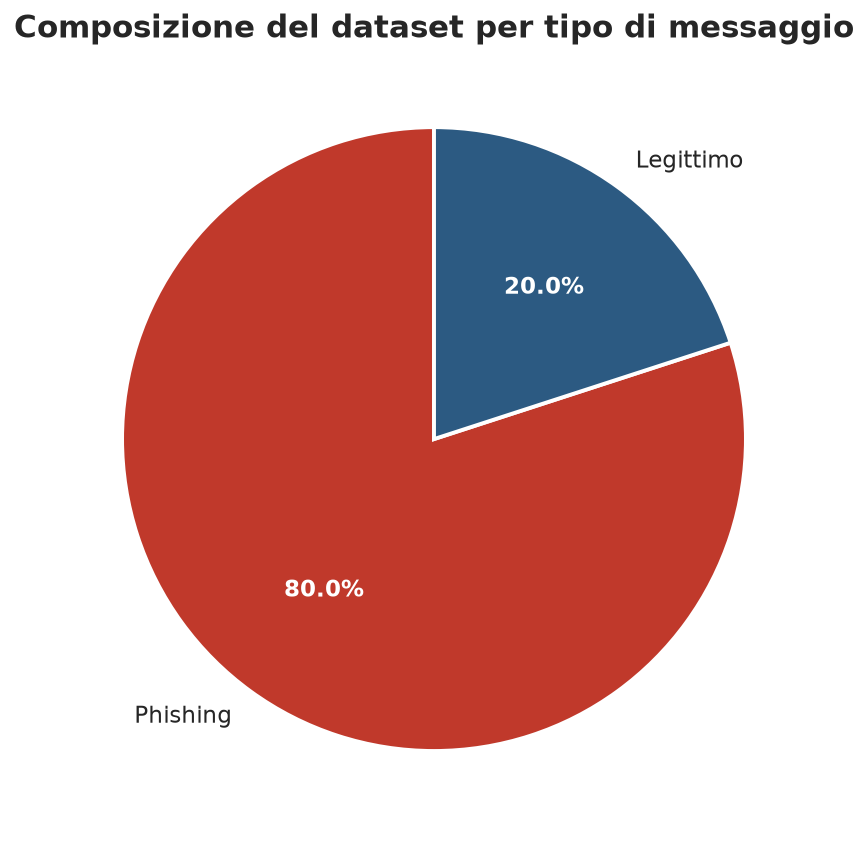

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 1.</b> Ripartizione delle interazioni simulate tra messaggi di phishing e messaggi legittimi.</div>

In [38]:

composizione = (
    work["message_type"].value_counts(normalize=True)
    .rename_axis("Tipo di messaggio").reset_index(name="Percentuale")
)
composizione["Tipo di messaggio"] = composizione["Tipo di messaggio"].str.capitalize()

fig, ax = plt.subplots(figsize=(6.2, 6.2))
colori_pie = [ACCENT if t.lower() == "phishing" else NEUTRAL for t in composizione["Tipo di messaggio"]]
wedges, _, autotexts = ax.pie(
    composizione["Percentuale"], labels=composizione["Tipo di messaggio"],
    autopct="%1.1f%%", startangle=90, colors=colori_pie,
    textprops={"fontsize": 12}, wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")
ax.set_title("Composizione del dataset per tipo di messaggio")
chiudi_figura(fig, "01_composizione_dataset",
              "Ripartizione delle interazioni simulate tra messaggi di phishing e messaggi legittimi.")


## 3. Analisi generale delle decisioni

Questa sezione presenta la distribuzione delle decisioni comportamentali iniziali e degli esiti
del flusso simulato, indipendentemente dal tipo di messaggio, per fornire una panoramica
d'insieme prima delle analisi disaggregate.

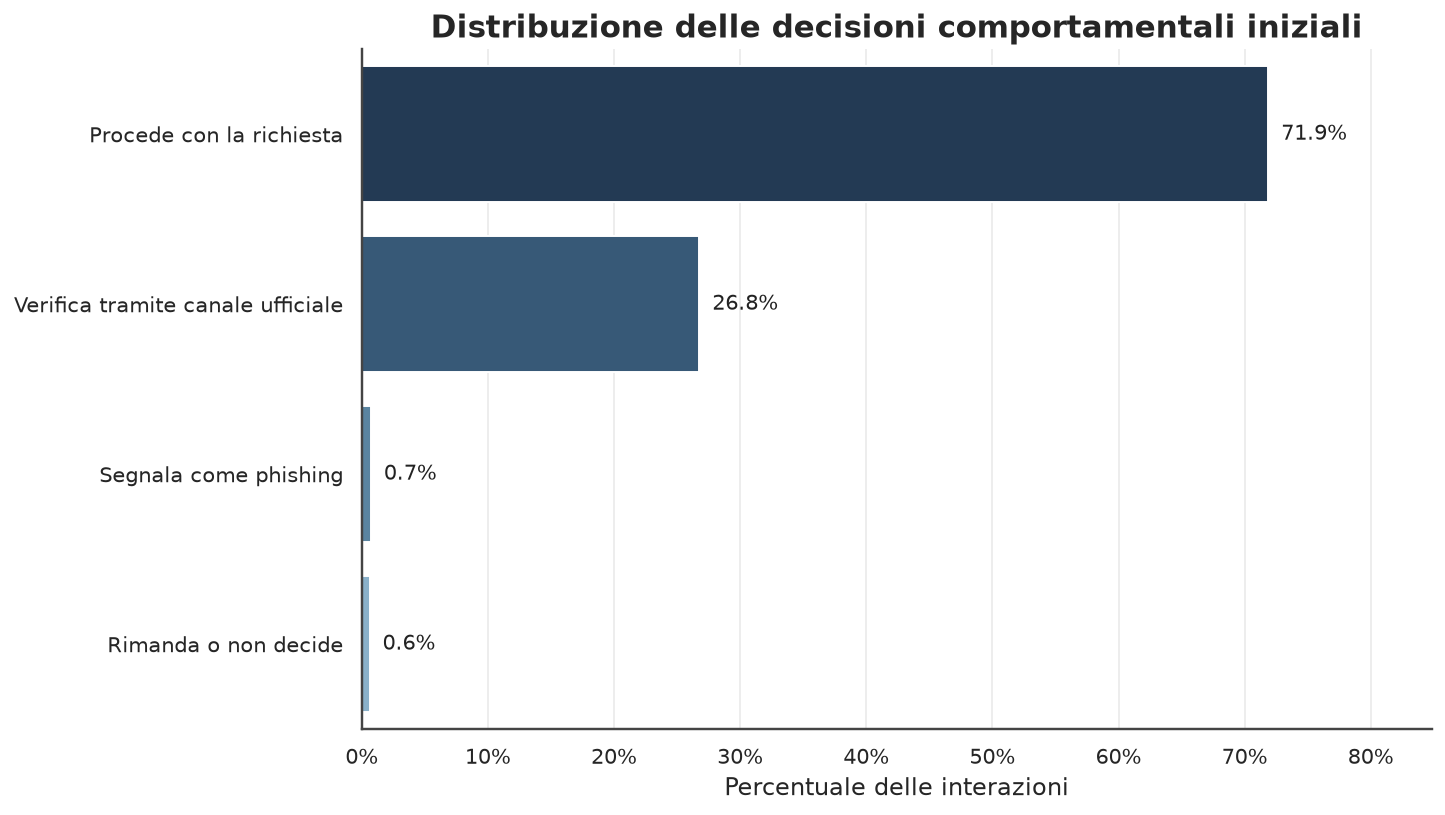

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 2.</b> Distribuzione percentuale della decisione comportamentale iniziale assunta dagli agenti, su tutte le interazioni simulate.</div>

In [39]:

decisioni = (
    work["decision"].map(etichetta)
    .value_counts(normalize=True)
    .rename_axis("Decisione").reset_index(name="Percentuale")
)

fig, ax = plt.subplots(figsize=(10.5, 6))
sns.barplot(data=decisioni, x="Percentuale", y="Decisione", hue="Decisione",
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("Distribuzione delle decisioni comportamentali iniziali")
ax.set_xlabel("Percentuale delle interazioni")
ax.set_ylabel("")
ax.set_xlim(0, decisioni["Percentuale"].max() * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
annota_barre(ax, orient="h")
chiudi_figura(fig, "02_distribuzione_decisioni",
              "Distribuzione percentuale della decisione comportamentale iniziale assunta dagli agenti, "
              "su tutte le interazioni simulate.")


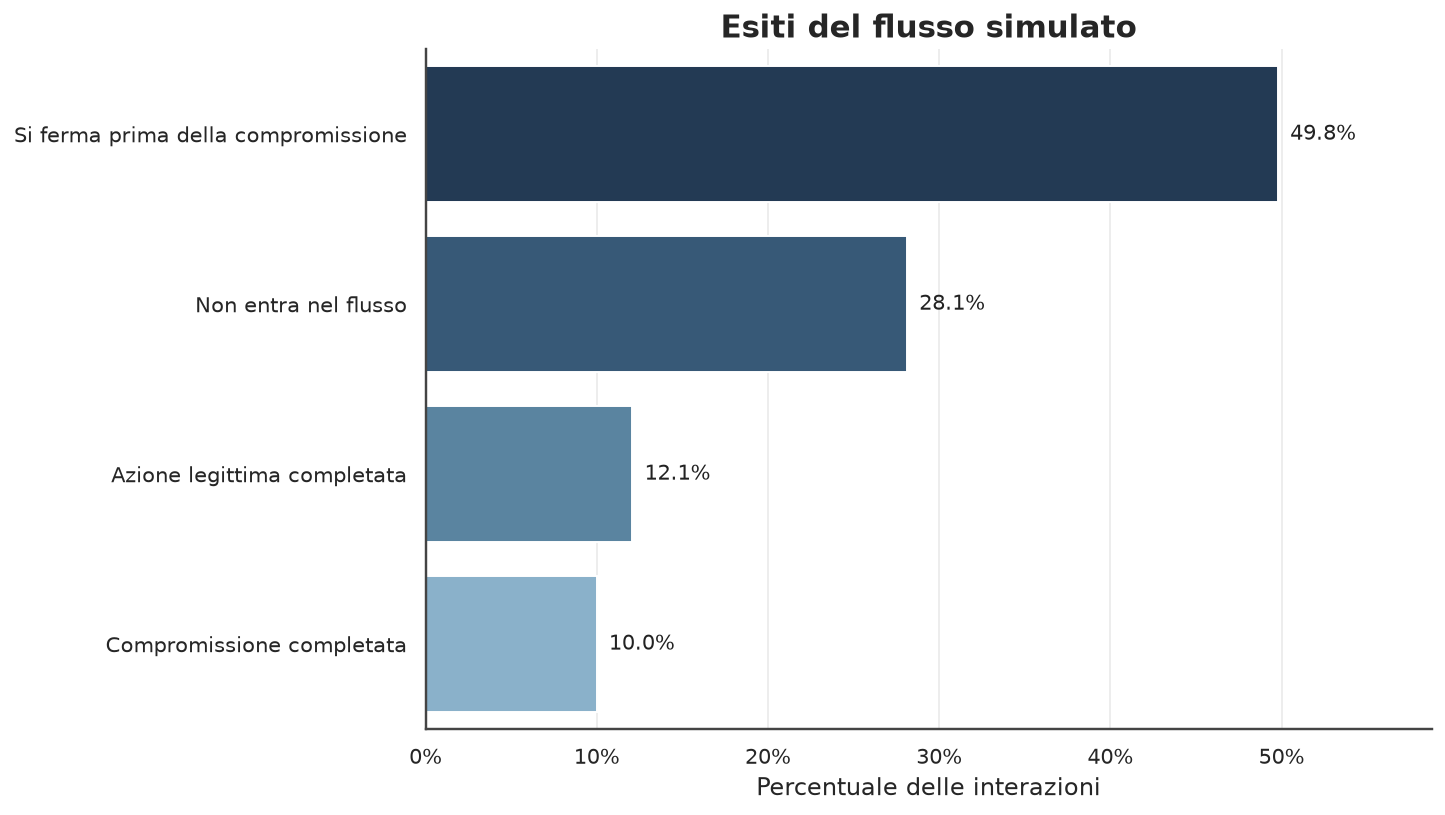

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 3.</b> Distribuzione percentuale degli esiti del flusso comportamentale simulato, dall'ingresso nel flusso fino alla compromissione o all'interruzione.</div>

In [40]:

esiti = (
    work["flow_outcome"].map(etichetta)
    .value_counts(normalize=True)
    .rename_axis("Esito").reset_index(name="Percentuale")
)

fig, ax = plt.subplots(figsize=(10.5, 6))
sns.barplot(data=esiti, x="Percentuale", y="Esito", hue="Esito",
            palette=sns.color_palette(["#4f86ab"], len(esiti)) if False else PALETTE,
            legend=False, ax=ax)
ax.set_title("Esiti del flusso simulato")
ax.set_xlabel("Percentuale delle interazioni")
ax.set_ylabel("")
ax.set_xlim(0, esiti["Percentuale"].max() * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
annota_barre(ax, orient="h")
chiudi_figura(fig, "03_esiti_flusso",
              "Distribuzione percentuale degli esiti del flusso comportamentale simulato, dall'ingresso "
              "nel flusso fino alla compromissione o all'interruzione.")


## 4. Analisi delle vittime

Questa sezione individua le categorie di agenti sintetici con il tasso di compromissione più
elevato, isolando in particolare l'effetto della fascia d'età. L'obiettivo è identificare i
profili più vulnerabili all'interno del disegno sperimentale.

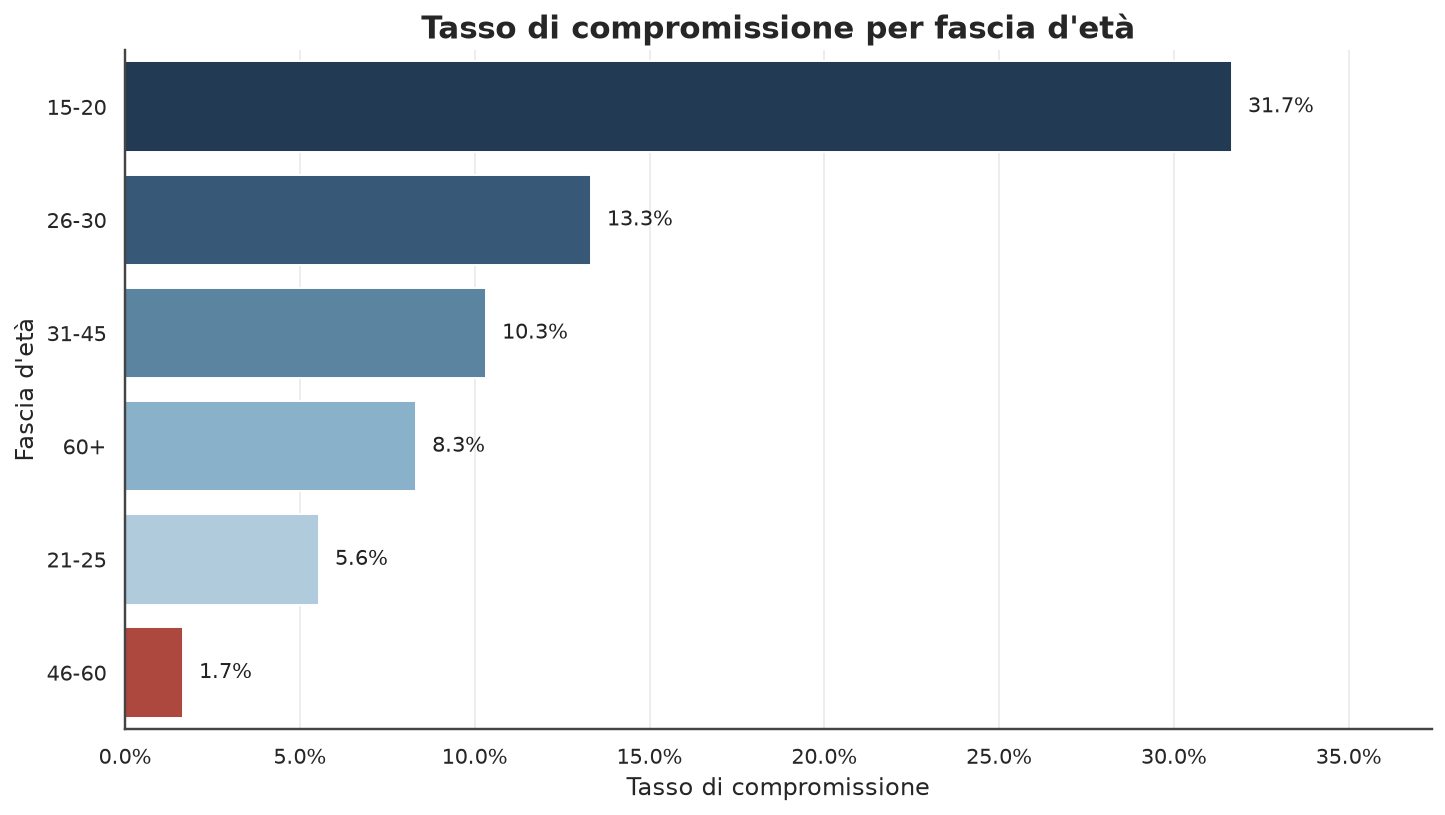

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 4.</b> Tasso di compromissione osservato per fascia d'età, calcolato su tutte le interazioni della fascia (phishing e messaggi legittimi inclusi).</div>

Fascia d'età,N. interazioni,Tasso di compromissione
15-20,60,31.7%
26-30,180,13.3%
31-45,300,10.3%
60+,120,8.3%
21-25,180,5.6%
46-60,120,1.7%


In [41]:

eta = (
    work.groupby("age_group", dropna=False)
    .agg(totale=("compromised", "size"), tasso_compromesso=("compromised", "mean"))
    .reset_index().sort_values("tasso_compromesso", ascending=False)
)

fig, ax = plt.subplots(figsize=(10.5, 6))
sns.barplot(data=eta, x="tasso_compromesso", y="age_group", hue="age_group",
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("Tasso di compromissione per fascia d'età")
ax.set_xlabel("Tasso di compromissione")
ax.set_ylabel("Fascia d'età")
ax.set_xlim(0, eta["tasso_compromesso"].max() * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
annota_barre(ax, orient="h")
chiudi_figura(fig, "04_compromissione_per_eta",
              "Tasso di compromissione osservato per fascia d'età, calcolato su tutte le interazioni "
              "della fascia (phishing e messaggi legittimi inclusi).")

display(tabella(
    eta[["age_group", "totale", "tasso_compromesso"]]
       .rename(columns={"age_group": "Fascia d'età", "totale": "N. interazioni",
                          "tasso_compromesso": "Tasso di compromissione"}),
    "Tasso di compromissione e numerosità campionaria per fascia d'età.",
    percent_cols=["Tasso di compromissione"], n_color_col="N. interazioni",
))
salva_tabella_latex(
    eta[["age_group", "totale", "tasso_compromesso"]]
       .rename(columns={"age_group": "Fascia d'età", "totale": "N. interazioni",
                          "tasso_compromesso": "Tasso di compromissione"}),
    "tab04_compromissione_per_eta",
    "Tasso di compromissione e numerosità campionaria per fascia d'età.",
    percent_cols=["Tasso di compromissione"],
)


## 5. Analisi dei messaggi

Vengono qui isolati gli scenari di phishing più efficaci, ovvero quelli che hanno prodotto il
tasso di compromissione più alto tra gli agenti esposti. Questa classifica è utile per
discutere, nel capitolo di tesi, quali leve persuasive (urgenza, personalizzazione, canale)
risultano più efficaci.

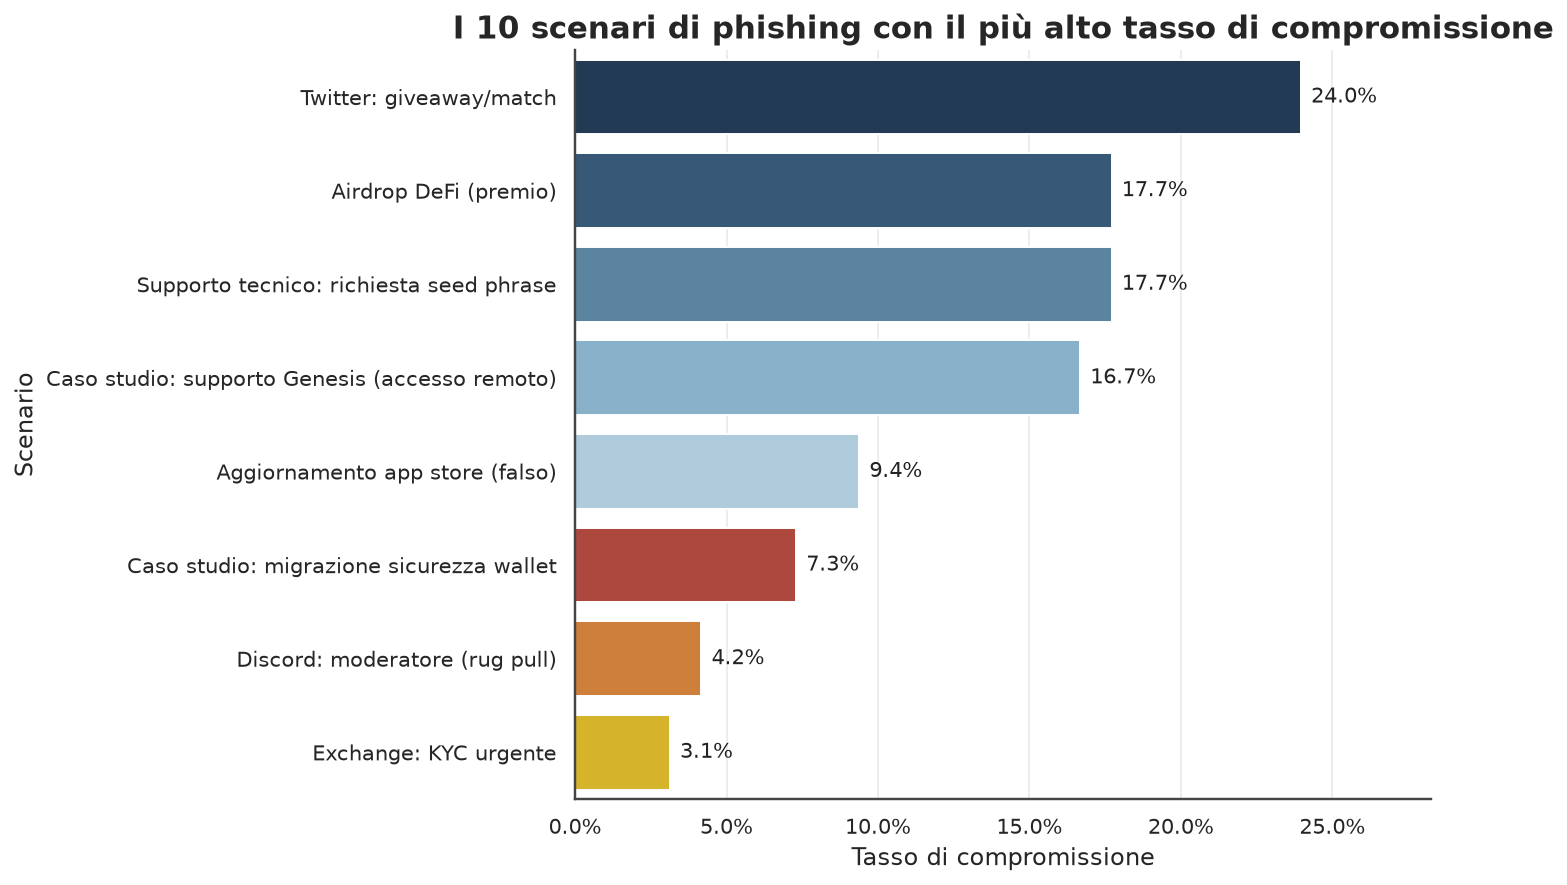

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 5.</b> Primi dieci scenari di phishing per tasso di compromissione tra gli agenti esposti al rispettivo messaggio.</div>

Scenario,Descrizione,N. esposizioni,Tasso di compromissione
Twitter: giveaway/match,"Giveaway su social con schema 'inviami 1 ETH, ti mando 2 ETH'",96,24.0%
Airdrop DeFi (premio),Airdrop DeFi con APY molto elevati,96,17.7%
Supporto tecnico: richiesta seed phrase,Finto supporto tecnico che chiede seed phrase,96,17.7%
Caso studio: supporto Genesis (accesso remoto),Scenario mirato ispirato al caso studio del 18 agosto 2024: falsa assistenza sicurezza Google/Gemini e richiesta di accesso remoto,96,16.7%
Aggiornamento app store (falso),Notifica push che invita a scaricare una falsa app wallet,96,9.4%
Caso studio: migrazione sicurezza wallet,Scenario mirato ispirato al caso studio: falsa procedura di messa in sicurezza di un wallet locale,96,7.3%
Discord: moderatore (rug pull),Finto moderatore Discord che invia link a dApp malevola,96,4.2%
Exchange: KYC urgente,Finta mail dell'exchange che minaccia blocco conto se non aggiorni KYC,96,3.1%


In [42]:

scenario = (
    work[work["message_type"].eq(PHISHING_TYPE)]
    .groupby(["message_id", "scenario_description"], dropna=False)
    .agg(totale=("compromised", "size"),
         tasso_compromesso=("compromised", "mean"),
         ingresso=("entered_flow", "mean"),
         stop=("stopped_before_compromise", "mean"))
    .reset_index().sort_values("tasso_compromesso", ascending=False).head(10)
)
scenario["Scenario"] = scenario["message_id"].map(etichetta)

fig, ax = plt.subplots(figsize=(10.5, 6.5))
sns.barplot(data=scenario, x="tasso_compromesso", y="Scenario", hue="Scenario",
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("I 10 scenari di phishing con il più alto tasso di compromissione")
ax.set_xlabel("Tasso di compromissione")
ax.set_ylabel("Scenario")
ax.set_xlim(0, scenario["tasso_compromesso"].max() * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
annota_barre(ax, orient="h")
chiudi_figura(fig, "05_top10_scenari_phishing",
              "Primi dieci scenari di phishing per tasso di compromissione tra gli agenti esposti al "
              "rispettivo messaggio.")

display(tabella(
    scenario[["Scenario", "scenario_description", "totale", "tasso_compromesso"]]
        .rename(columns={"scenario_description": "Descrizione",
                           "totale": "N. esposizioni", "tasso_compromesso": "Tasso di compromissione"}),
    "Dettaglio dei dieci scenari di phishing più efficaci.",
    percent_cols=["Tasso di compromissione"],
))
salva_tabella_latex(
    scenario[["Scenario", "scenario_description", "totale", "tasso_compromesso"]]
        .rename(columns={"scenario_description": "Descrizione",
                           "totale": "N. esposizioni", "tasso_compromesso": "Tasso di compromissione"}),
    "tab05_top10_scenari_phishing",
    "Dettaglio dei dieci scenari di phishing più efficaci.",
    percent_cols=["Tasso di compromissione"],
)


## 6. Confronto phishing vs. messaggi legittimi

Il confronto tra messaggi di phishing e messaggi legittimi consente di valutare la capacità
discriminante del comportamento simulato: un buon framework dovrebbe mostrare tassi di
compromissione e segnalazione chiaramente differenziati tra le due categorie.

In [43]:

confronto = (
    work.groupby("message_type", dropna=False)
    .agg(totale=("compromised", "size"),
         compromesso=("compromised", "mean"),
         verifica=("verified", "mean"),
         segnalazione=("reported", "mean"),
         ignorato=("ignored", "mean"),
         rimandato=("delayed", "mean"))
    .reset_index()
)
confronto["message_type"] = confronto["message_type"].str.capitalize()

confronto_disp = confronto.rename(columns={
    "message_type": "Tipo messaggio", "totale": "Campione",
    "compromesso": "Tasso compromesso", "verifica": "Tasso verifica",
    "segnalazione": "Tasso segnalazione", "ignorato": "Tasso ignorato",
    "rimandato": "Tasso rimandato",
})
display(tabella(confronto_disp,
                 "Indicatori comportamentali a confronto tra messaggi phishing e messaggi legittimi.",
                 percent_cols=["Tasso compromesso", "Tasso verifica", "Tasso segnalazione",
                                "Tasso ignorato", "Tasso rimandato"]))
salva_tabella_latex(confronto_disp, "tab06_confronto_phishing_legittimi",
                     "Indicatori comportamentali a confronto tra messaggi phishing e messaggi legittimi.",
                     percent_cols=["Tasso compromesso", "Tasso verifica", "Tasso segnalazione",
                                    "Tasso ignorato", "Tasso rimandato"])


Tipo messaggio,Campione,Tasso compromesso,Tasso verifica,Tasso segnalazione,Tasso ignorato,Tasso rimandato
Legittimo,192,0.0%,38.0%,0.0%,0.0%,1.6%
Phishing,768,12.5%,24.0%,0.9%,0.0%,0.4%


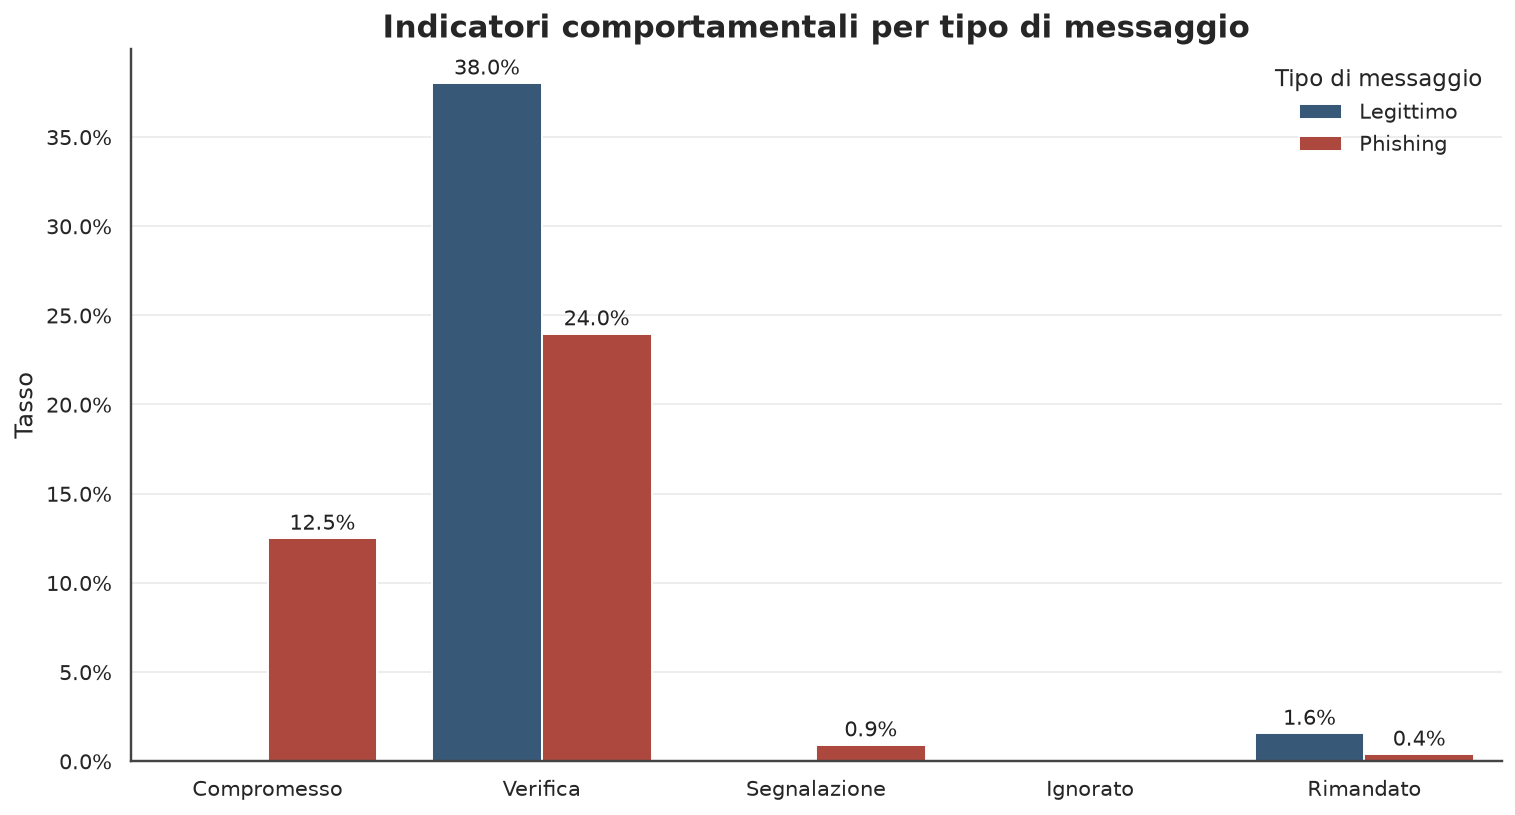

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 6.</b> Confronto dei principali indicatori comportamentali (compromissione, verifica, segnalazione, ignoramento, rimando) tra messaggi phishing e messaggi legittimi.</div>

In [44]:

confronto_long = confronto.melt(
    id_vars="message_type",
    value_vars=["compromesso", "verifica", "segnalazione", "ignorato", "rimandato"],
    var_name="Indicatore", value_name="Tasso",
)
confronto_long["Indicatore"] = confronto_long["Indicatore"].str.capitalize()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=confronto_long, x="Indicatore", y="Tasso", hue="message_type",
            palette=[NEUTRAL, ACCENT], ax=ax)
ax.set_title("Indicatori comportamentali per tipo di messaggio")
ax.set_xlabel("")
ax.set_ylabel("Tasso")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title="Tipo di messaggio", frameon=False)
annota_barre(ax, orient="v")
chiudi_figura(fig, "06_confronto_indicatori",
              "Confronto dei principali indicatori comportamentali (compromissione, verifica, "
              "segnalazione, ignoramento, rimando) tra messaggi phishing e messaggi legittimi.")


## 7. Profilo psicometrico del rischio

Ogni archetipo e descritto da cinque tratti comportamentali espressi su scala ordinale
(da *molto bassa* a *molto alta*). Incrociando ciascun tratto con l'esito sui messaggi di
phishing si ottiene una relazione dose-risposta: si osserva come il tasso di compromissione
vari al variare dell'intensita del tratto. Le curve rendono immediatamente leggibile quali
caratteristiche **espongono** al rischio (impulsivita, fiducia nei brand) e quali **proteggono**
(attenzione, avversione al rischio, competenza tecnica).

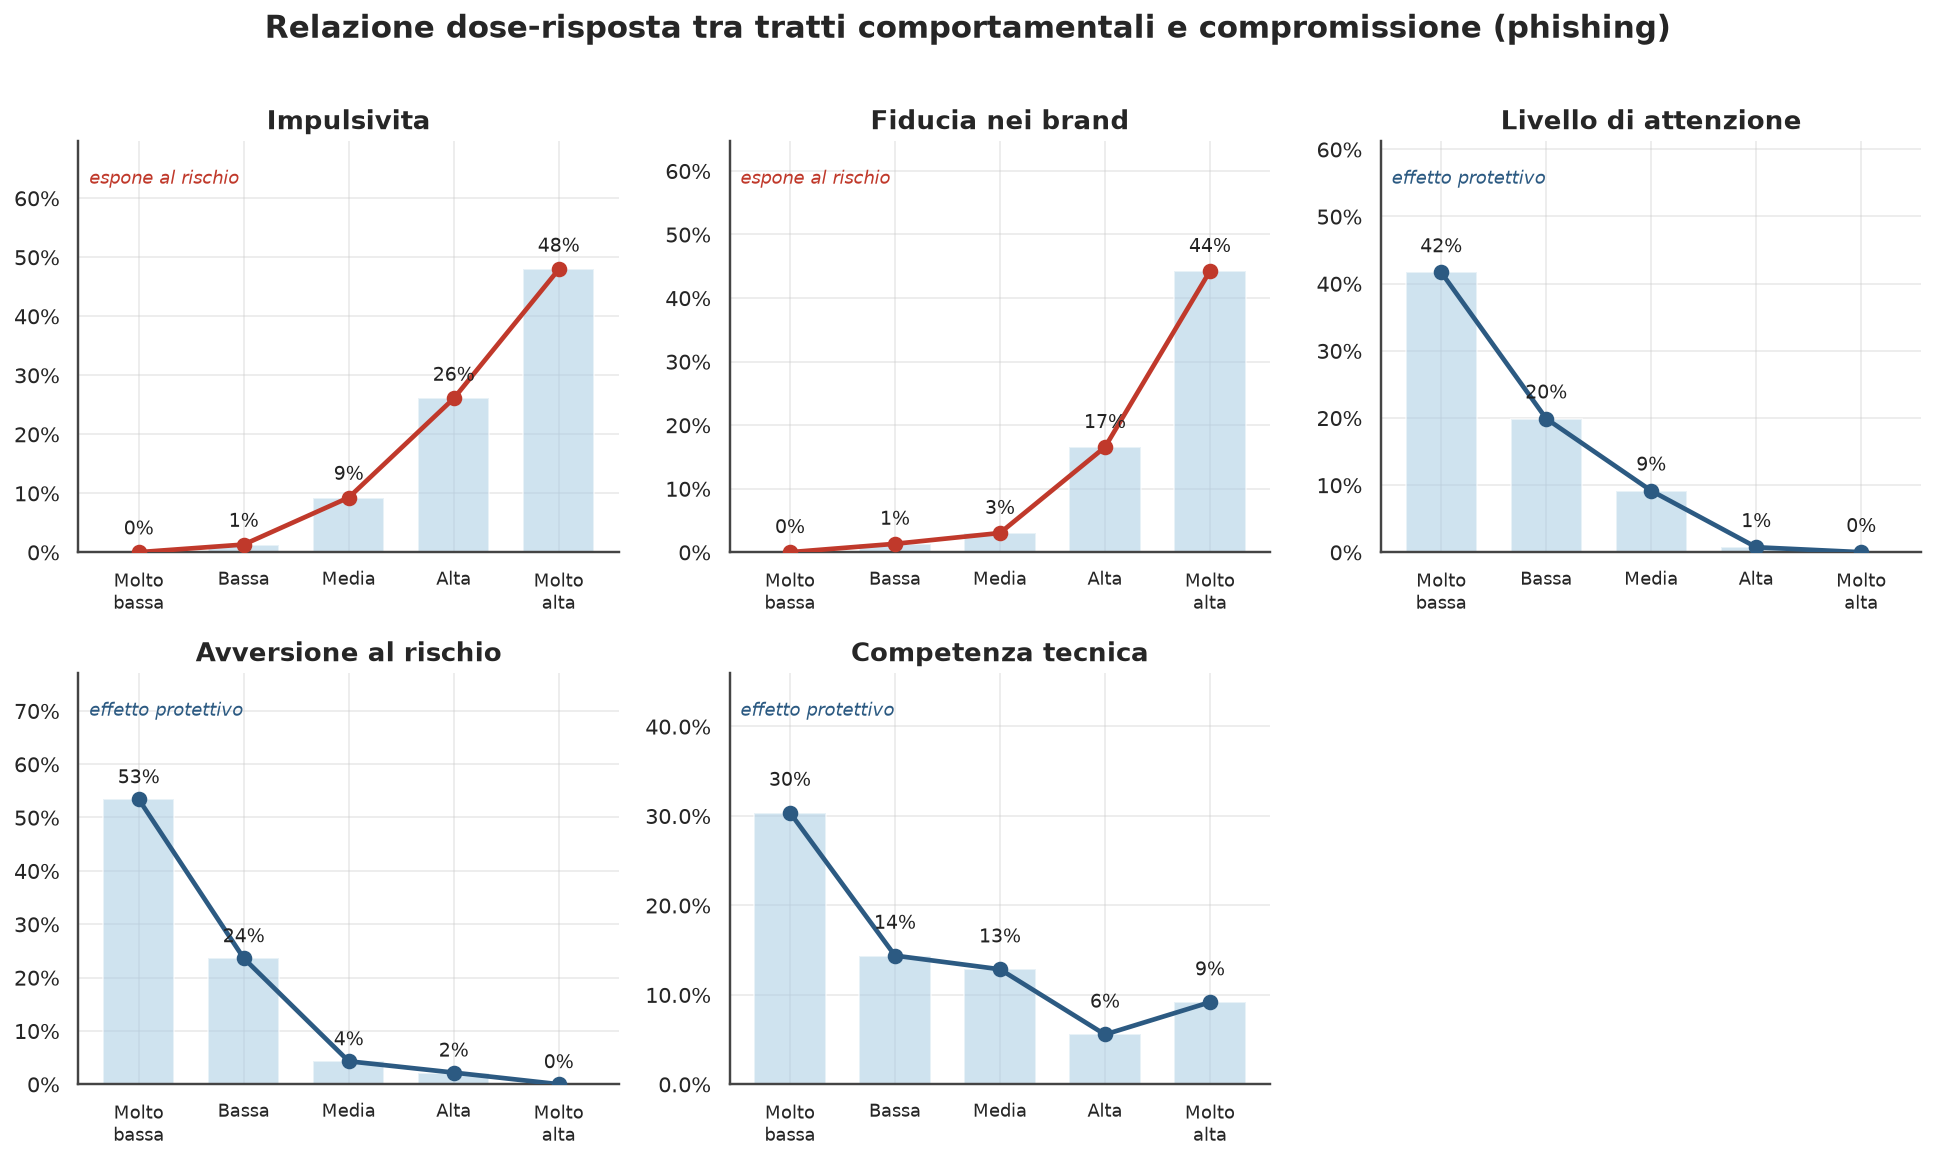

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 7.</b> Tasso di compromissione sui messaggi di phishing in funzione dell'intensita di ciascun tratto comportamentale. Impulsivita e fiducia nei brand aumentano il rischio; attenzione, avversione al rischio e competenza tecnica lo riducono.</div>

In [45]:
import numpy as np

tratti = {
    "impulsiveness": ("Impulsivita", "rischio"),
    "trust_in_brands": ("Fiducia nei brand", "rischio"),
    "attention_level": ("Livello di attenzione", "protettivo"),
    "risk_aversion": ("Avversione al rischio", "protettivo"),
    "tech_savvy": ("Competenza tecnica", "protettivo"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8.2))
axes = axes.ravel()
for k, (col, (titolo, segno)) in enumerate(tratti.items()):
    serie = phish.groupby(col)["compromised"].mean().reindex(ORDINE_LIVELLI)
    x = np.arange(len(ORDINE_LIVELLI))
    y = serie.values.astype(float)
    ax = axes[k]
    colore = ACCENT if segno == "rischio" else NEUTRAL
    ax.bar(x, np.nan_to_num(y), color="#a9cce3", alpha=0.55, zorder=1, width=0.68)
    ax.plot(x, y, marker="o", markersize=7, color=colore, lw=2.4, zorder=3)
    for xi, yi in zip(x, y):
        if not np.isnan(yi):
            ax.text(xi, yi + 0.03, f"{yi:.0%}", ha="center", fontsize=10, color="#222")
    ax.set_title(titolo, fontsize=13.5)
    ax.set_xticks(x); ax.set_xticklabels(ET_LIVELLI, fontsize=9.5)
    ax.set_ylim(0, min(1.0, np.nanmax(y) * 1.35 + 0.05) if np.nanmax(y) > 0 else 0.1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    tag = "espone al rischio" if segno == "rischio" else "effetto protettivo"
    ax.text(0.02, 0.93, tag, transform=ax.transAxes, fontsize=9.5, style="italic",
            color=colore, va="top")
axes[-1].axis("off")
fig.suptitle("Relazione dose-risposta tra tratti comportamentali e compromissione (phishing)",
             fontsize=16, fontweight="bold", y=1.01)
chiudi_figura(fig, "07_tratti_dose_risposta",
              "Tasso di compromissione sui messaggi di phishing in funzione dell'intensita di ciascun "
              "tratto comportamentale. Impulsivita e fiducia nei brand aumentano il rischio; attenzione, "
              "avversione al rischio e competenza tecnica lo riducono.")


## 8. Vulnerabilita per archetipo

Il grafico seguente ordina i sedici archetipi sintetici per tasso di compromissione sui
messaggi di phishing, offrendo una classifica diretta dei profili piu esposti. Il grafico a
barre in composizione percentuale mostra invece **come** ciascun archetipo distribuisce le
proprie decisioni iniziali, distinguendo i profili che tendono a procedere da quelli che
verificano o segnalano.

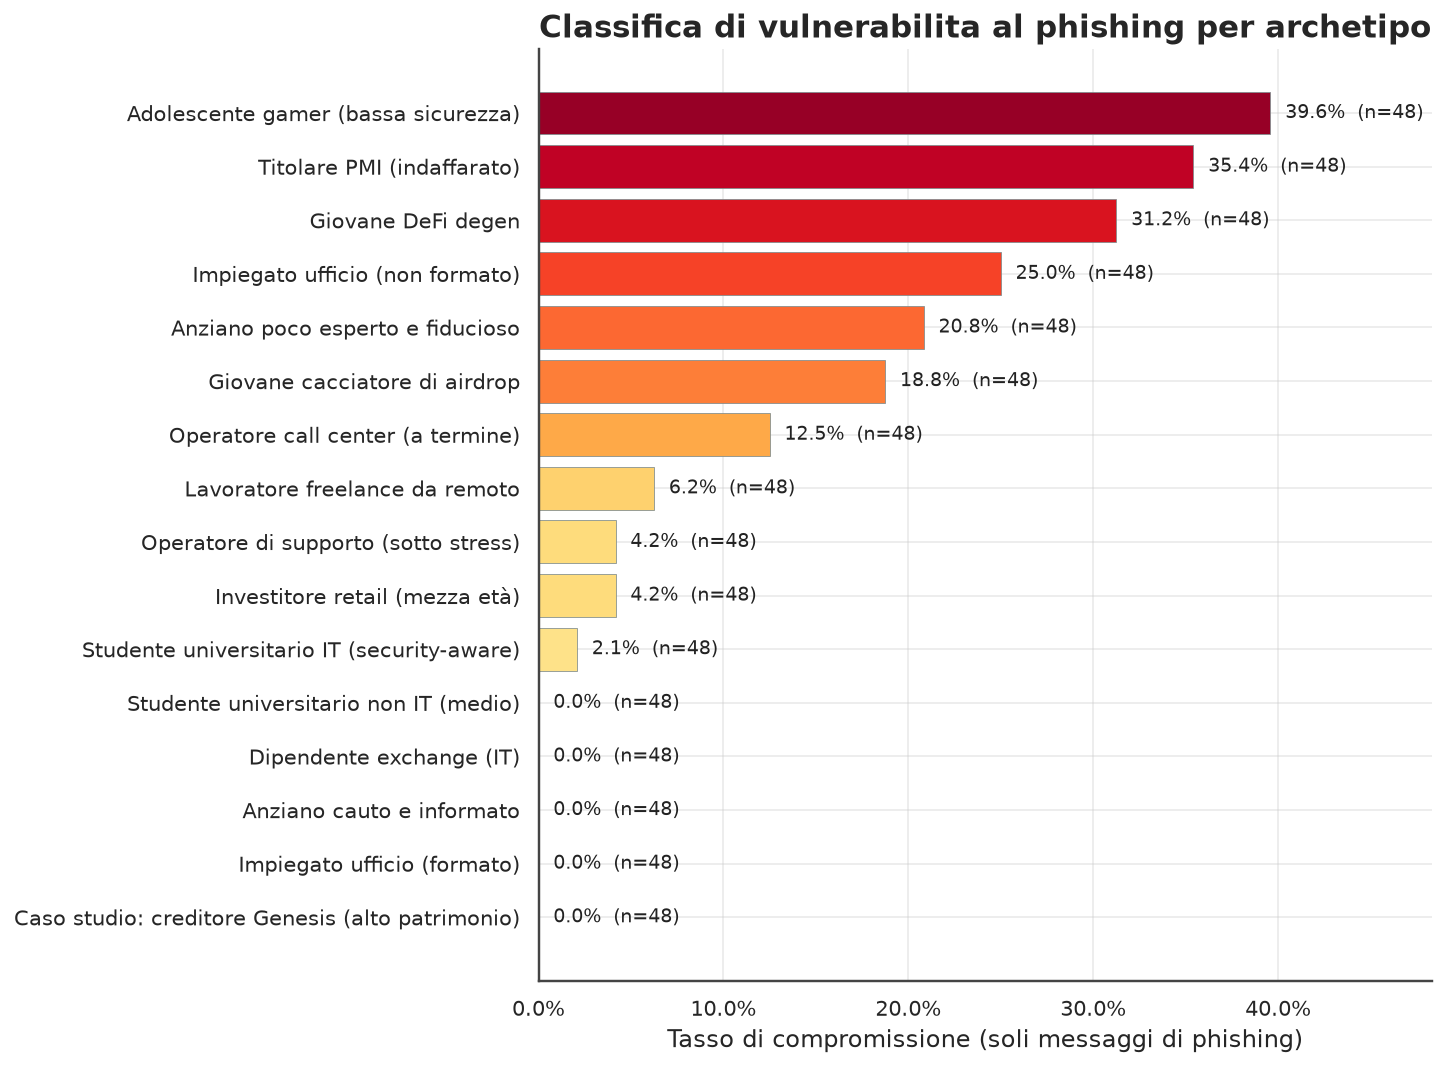

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 8.</b> Tasso di compromissione per archetipo comportamentale sui soli messaggi di phishing, con numerosita delle esposizioni. La scala cromatica evidenzia i profili piu esposti.</div>

Archetipo,N. esposizioni,Tasso di compromissione
Adolescente gamer (bassa sicurezza),48,39.6%
Titolare PMI (indaffarato),48,35.4%
Giovane DeFi degen,48,31.2%
Impiegato ufficio (non formato),48,25.0%
Anziano poco esperto e fiducioso,48,20.8%
Giovane cacciatore di airdrop,48,18.8%
Operatore call center (a termine),48,12.5%
Lavoratore freelance da remoto,48,6.2%
Operatore di supporto (sotto stress),48,4.2%
Investitore retail (mezza età),48,4.2%


In [46]:
arch = (
    phish.groupby("archetype_id")
    .agg(totale=("compromised", "size"), tasso=("compromised", "mean"))
    .reset_index().sort_values("tasso", ascending=True)
)
arch["Archetipo"] = arch["archetype_id"].map(etichetta)

from matplotlib.colors import Normalize
cmap = plt.get_cmap("YlOrRd")
nrm = Normalize(vmin=0, vmax=max(arch["tasso"].max(), 0.01))
colori = [cmap(0.15 + 0.8 * nrm(v)) for v in arch["tasso"]]

fig, ax = plt.subplots(figsize=(10.5, 7.8))
ax.barh(arch["Archetipo"], arch["tasso"], color=colori, edgecolor="#7f8c8d", linewidth=0.4)
for i, (v, n) in enumerate(zip(arch["tasso"], arch["totale"])):
    ax.text(v + 0.008, i, f"{v:.1%}  (n={n})", va="center", fontsize=10, color="#222")
ax.set_xlim(0, arch["tasso"].max() * 1.22)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Tasso di compromissione (soli messaggi di phishing)")
ax.set_ylabel("")
ax.set_title("Classifica di vulnerabilita al phishing per archetipo")
chiudi_figura(fig, "08_ranking_archetipi",
              "Tasso di compromissione per archetipo comportamentale sui soli messaggi di phishing, "
              "con numerosita delle esposizioni. La scala cromatica evidenzia i profili piu esposti.")

display(tabella(
    arch.sort_values("tasso", ascending=False)[["Archetipo", "totale", "tasso"]]
        .rename(columns={"totale": "N. esposizioni", "tasso": "Tasso di compromissione"}),
    "Tasso di compromissione al phishing per archetipo comportamentale.",
    percent_cols=["Tasso di compromissione"], n_color_col="N. esposizioni",
))
salva_tabella_latex(
    arch.sort_values("tasso", ascending=False)[["Archetipo", "totale", "tasso"]]
        .rename(columns={"totale": "N. esposizioni", "tasso": "Tasso di compromissione"}),
    "tab07_vulnerabilita_archetipi",
    "Tasso di compromissione al phishing per archetipo comportamentale.",
    percent_cols=["Tasso di compromissione"],
)


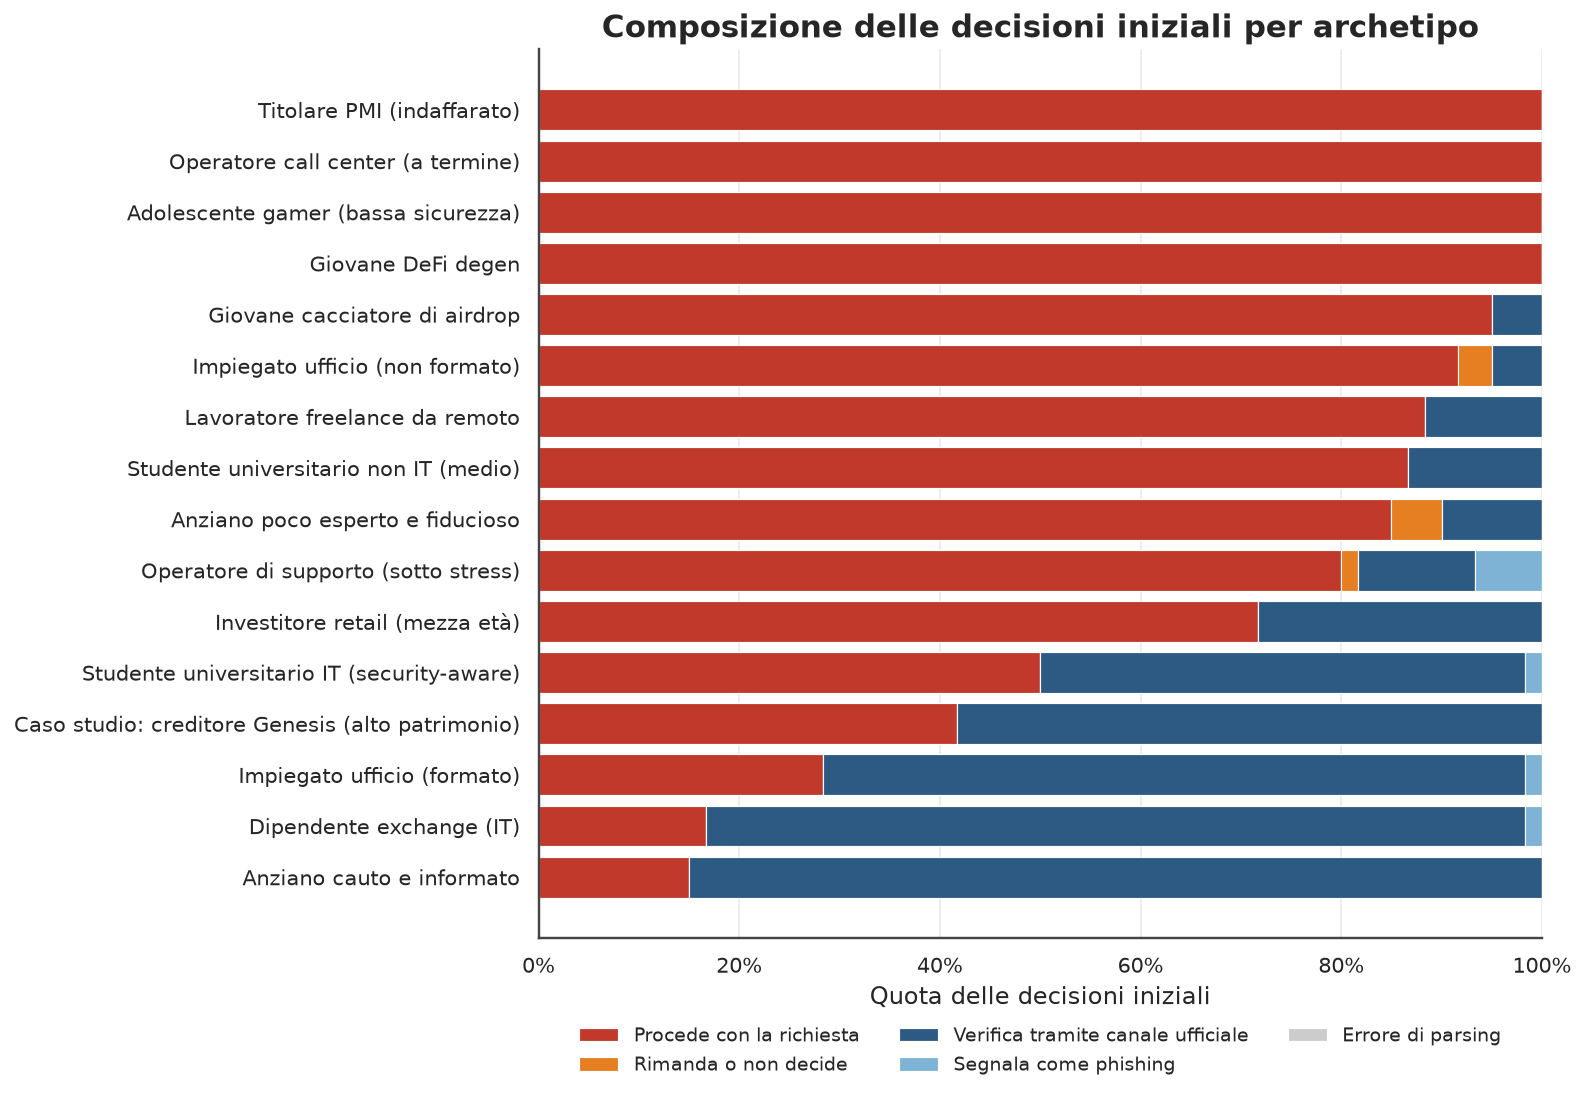

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 9.</b> Ripartizione percentuale delle decisioni comportamentali iniziali all'interno di ciascun archetipo, ordinata per propensione a procedere con la richiesta.</div>

In [47]:
# Composizione percentuale delle decisioni iniziali per ciascun archetipo (barre 100%)
ordine_dec = ["Procede con la richiesta", "Rimanda o non decide",
              "Verifica tramite canale ufficiale", "Segnala come phishing", "Errore di parsing"]
colori_dec = {
    "Procede con la richiesta": ACCENT,
    "Rimanda o non decide": "#e67e22",
    "Verifica tramite canale ufficiale": "#2c5a82",
    "Segnala come phishing": "#7fb3d5",
    "Errore di parsing": "#cccccc",
}

ct = pd.crosstab(work["archetype_id"].map(etichetta), work["decision"].map(etichetta),
                 normalize="index")
for c in ordine_dec:
    if c not in ct.columns:
        ct[c] = 0.0
ct = ct[[c for c in ordine_dec if c in ct.columns]]
ct = ct.sort_values("Procede con la richiesta", ascending=True)

fig, ax = plt.subplots(figsize=(11.5, 8))
sinistra = np.zeros(len(ct))
for col in ct.columns:
    ax.barh(ct.index, ct[col].values, left=sinistra, label=col,
            color=colori_dec.get(col, "#999999"), edgecolor="white", linewidth=0.6)
    sinistra += ct[col].values
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Quota delle decisioni iniziali")
ax.set_ylabel("")
ax.set_title("Composizione delle decisioni iniziali per archetipo")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=10)
chiudi_figura(fig, "09_decisioni_per_archetipo",
              "Ripartizione percentuale delle decisioni comportamentali iniziali all'interno di ciascun "
              "archetipo, ordinata per propensione a procedere con la richiesta.")


## 9. Interazione archetipo-scenario e imbuto di compromissione

La mappa di calore incrocia i profili con i singoli scenari di phishing: ogni cella indica il
tasso di compromissione di quell'archetipo di fronte a quel messaggio. La lettura per righe
individua i profili robusti o fragili in generale; la lettura per colonne individua gli scenari
piu insidiosi a prescindere dal profilo. L'imbuto finale ricostruisce infine il percorso
aggregato dell'attacco, dall'esposizione fino alla compromissione.

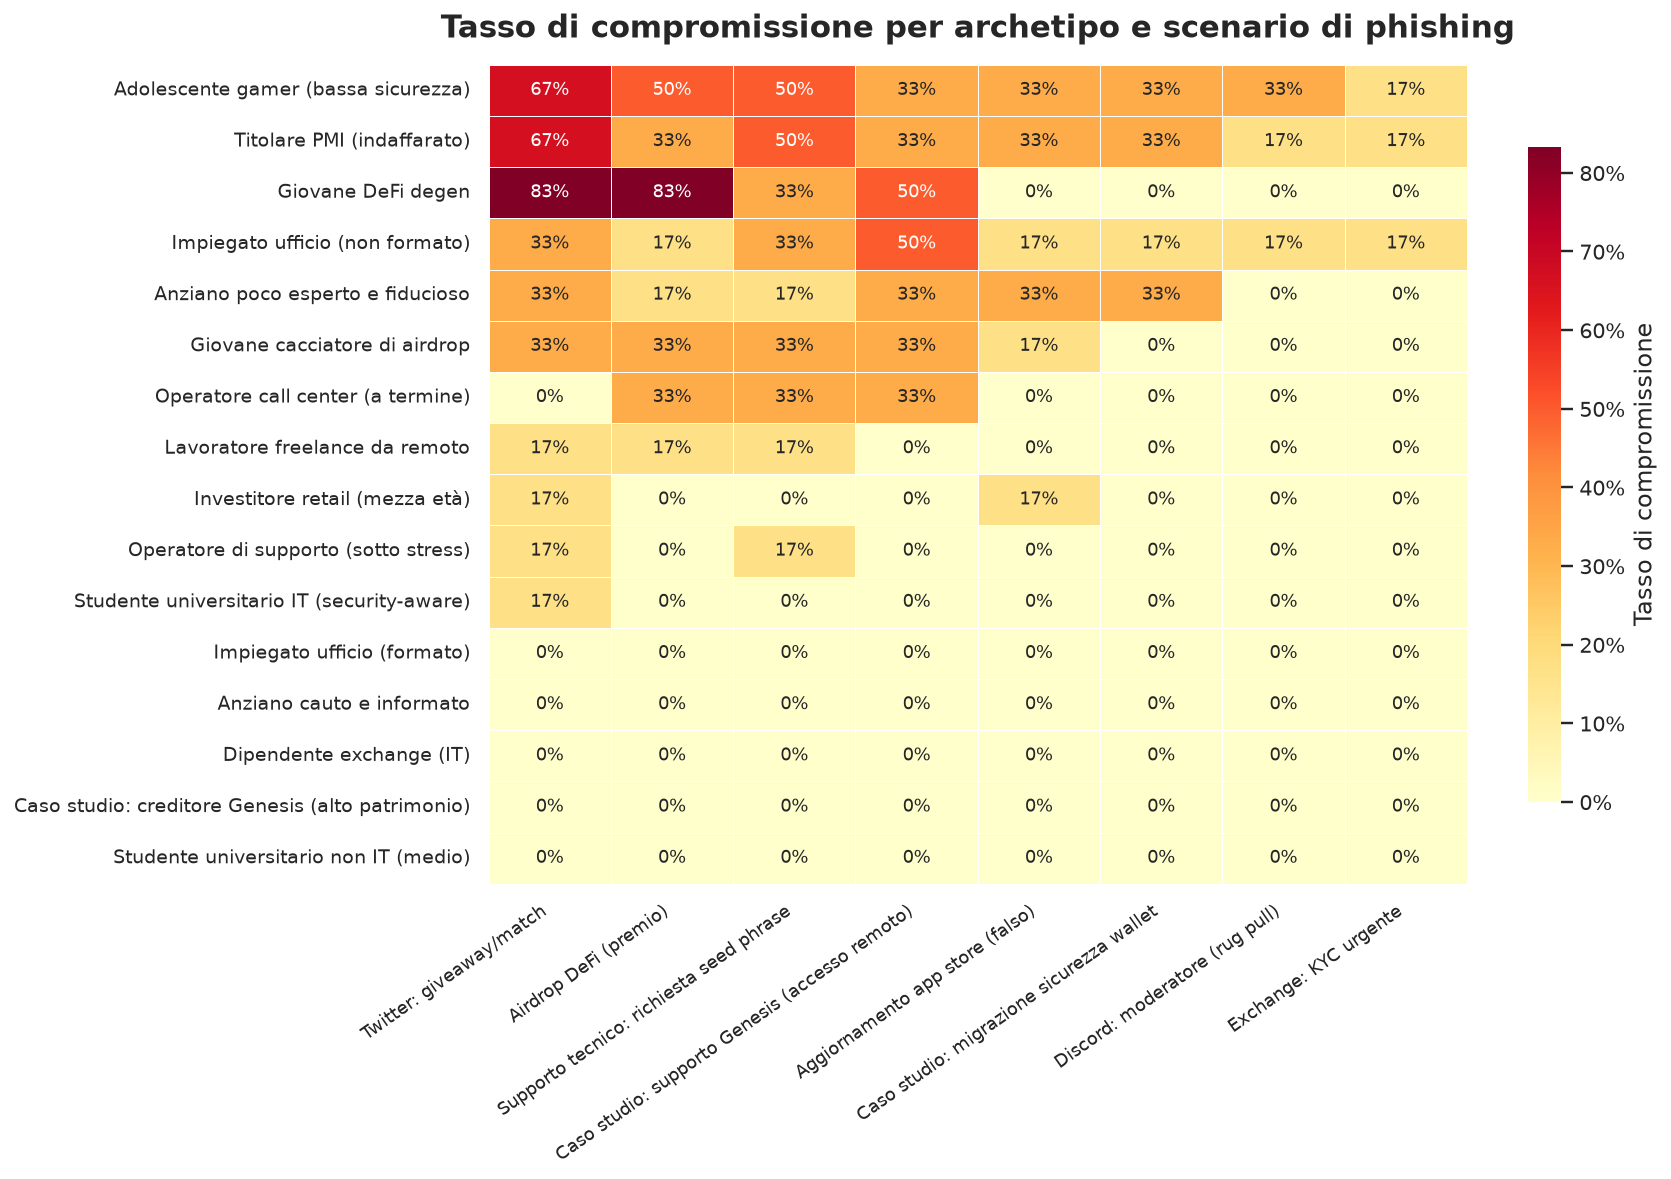

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 10.</b> Mappa di calore del tasso di compromissione incrociando archetipi (righe) e scenari di phishing (colonne). Righe e colonne sono ordinate per compromissione media decrescente.</div>

In [48]:
piv = phish.pivot_table(index="archetype_id", columns="message_id",
                        values="compromised", aggfunc="mean")
piv.index = [etichetta(i) for i in piv.index]
piv.columns = [etichetta(c) for c in piv.columns]
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
piv = piv[piv.mean(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12.5, 8.6))
sns.heatmap(piv, annot=True, fmt=".0%", cmap="YlOrRd", vmin=0,
            linewidths=0.5, linecolor="white", annot_kws={"fontsize": 9},
            cbar_kws={"label": "Tasso di compromissione", "shrink": 0.8}, ax=ax)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Tasso di compromissione per archetipo e scenario di phishing", pad=14)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
plt.setp(ax.get_yticklabels(), fontsize=10)
chiudi_figura(fig, "10_heatmap_archetipo_scenario",
              "Mappa di calore del tasso di compromissione incrociando archetipi (righe) e scenari di "
              "phishing (colonne). Righe e colonne sono ordinate per compromissione media decrescente.")


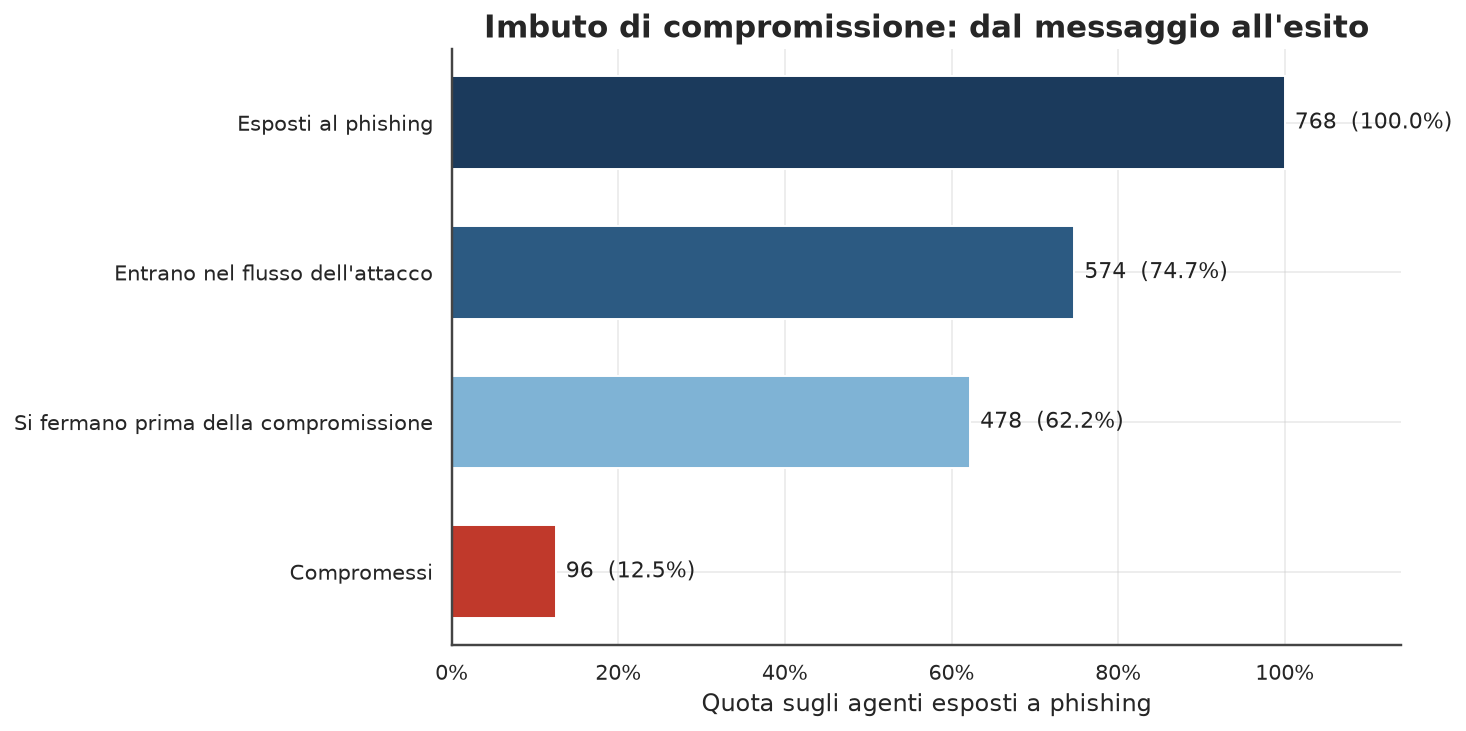

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 11.</b> Imbuto comportamentale sui soli messaggi di phishing: quota di agenti che entra nel flusso dell'attacco, che si arresta prima della compromissione e che viene infine compromessa.</div>

In [49]:
# Imbuto di compromissione sui messaggi di phishing
tot = len(phish)
tappe = [
    ("Esposti al phishing", tot),
    ("Entrano nel flusso dell'attacco", int(phish["entered_flow"].sum())),
    ("Si fermano prima della compromissione", int(phish["stopped_before_compromise"].sum())),
    ("Compromessi", int(phish["compromised"].sum())),
]
etich = [t[0] for t in tappe]
valori = [t[1] for t in tappe]
quote = [v / tot for v in valori]

fig, ax = plt.subplots(figsize=(10.5, 5.4))
colori = ["#1b3a5c", "#2c5a82", "#7fb3d5", ACCENT]
y = np.arange(len(tappe))
ax.barh(y, quote, color=colori, edgecolor="white", height=0.62)
for i, (v, q) in enumerate(zip(valori, quote)):
    ax.text(q + 0.012, i, f"{v:,}  ({q:.1%})", va="center", fontsize=11.5, color="#222")
ax.set_yticks(y); ax.set_yticklabels(etich)
ax.invert_yaxis()
ax.set_xlim(0, 1.14)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Quota sugli agenti esposti a phishing")
ax.set_ylabel("")
ax.set_title("Imbuto di compromissione: dal messaggio all'esito")
chiudi_figura(fig, "11_funnel_compromissione",
              "Imbuto comportamentale sui soli messaggi di phishing: quota di agenti che entra nel flusso "
              "dell'attacco, che si arresta prima della compromissione e che viene infine compromessa.")


## 10. Fattori di contesto: formazione, esperienza e canale

Oltre ai tratti di personalita, l'esito dipende da fattori di contesto. I pannelli seguenti
isolano l'effetto della formazione sulla sicurezza, dell'esperienza pregressa con le
criptovalute e del canale attraverso cui arriva il messaggio.

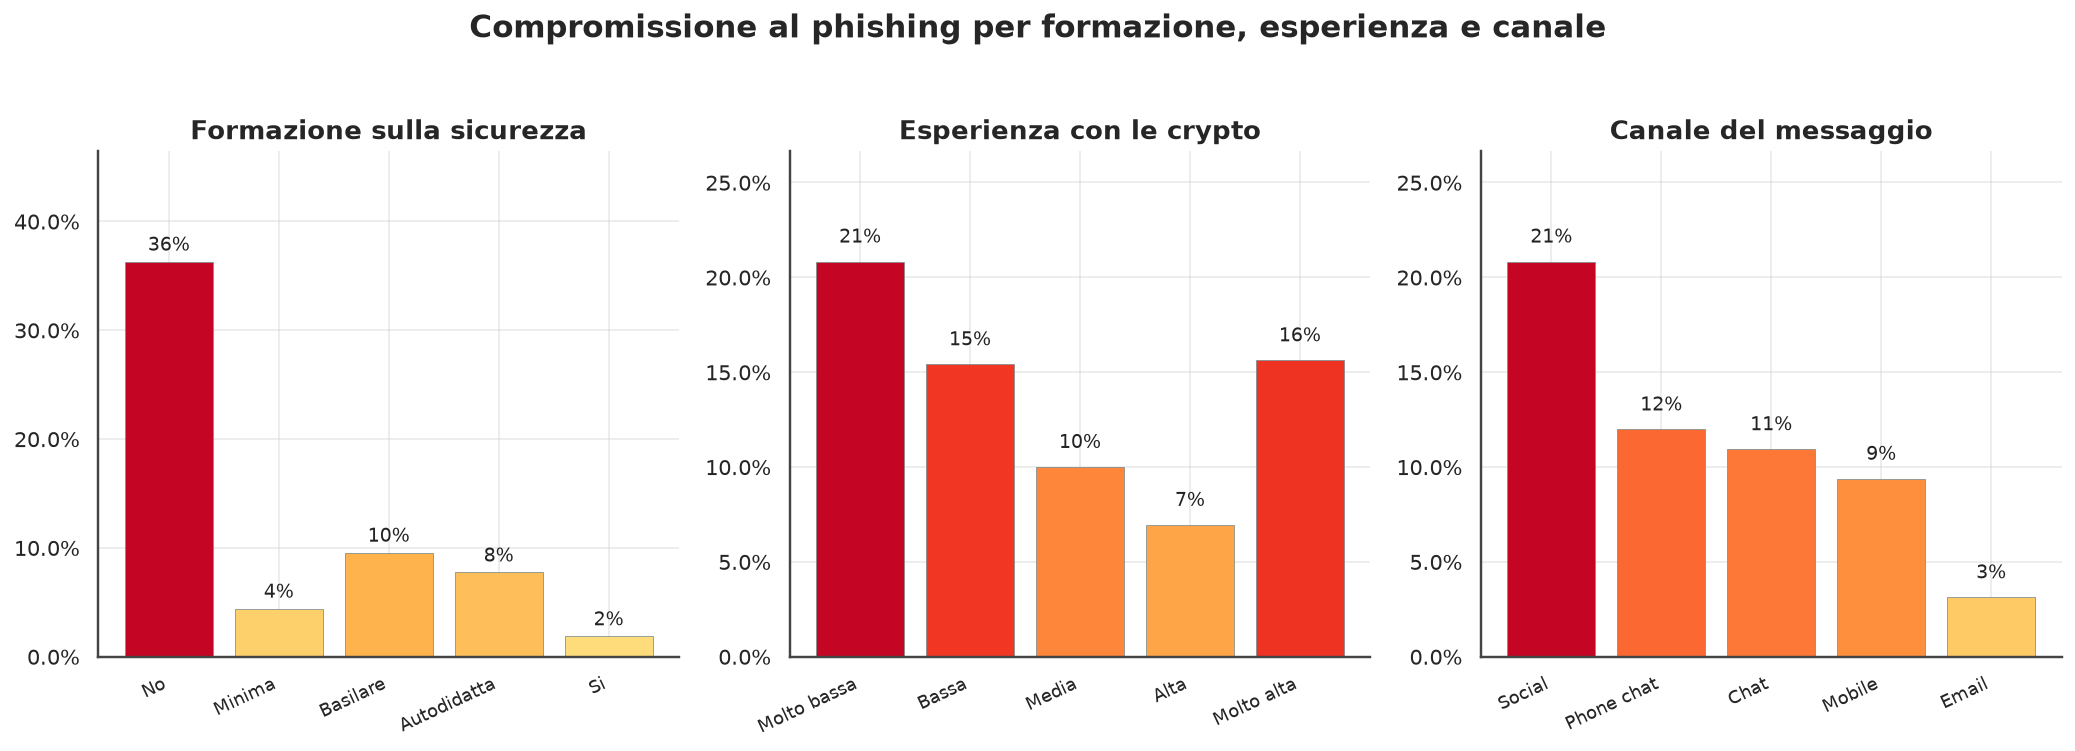

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 12.</b> Tasso di compromissione sui messaggi di phishing in funzione della formazione sulla sicurezza, dell'esperienza con le criptovalute e del canale di consegna del messaggio.</div>

In [50]:
specifiche = [
    ("security_training", "Formazione sulla sicurezza",
     ["no", "minima", "basilare", "autodidatta", "si"],
     ["No", "Minima", "Basilare", "Autodidatta", "Si"]),
    ("crypto_experience", "Esperienza con le crypto",
     ORDINE_LIVELLI, ["Molto bassa", "Bassa", "Media", "Alta", "Molto alta"]),
    ("channel", "Canale del messaggio", None, None),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (col, titolo, ordine, etlabels) in zip(axes, specifiche):
    s = phish.groupby(col)["compromised"].mean()
    if ordine:
        s = s.reindex(ordine).dropna()
        lab = [etlabels[ordine.index(i)] for i in s.index]
    else:
        s = s.sort_values(ascending=False)
        lab = [etichetta(i) for i in s.index]
    x = np.arange(len(s))
    colori = plt.get_cmap("YlOrRd")(0.2 + 0.65 * (s.values / max(s.values.max(), 0.01)))
    ax.bar(x, s.values, color=colori, edgecolor="#7f8c8d", linewidth=0.4)
    for xi, yi in zip(x, s.values):
        ax.text(xi, yi + 0.01, f"{yi:.0%}", ha="center", fontsize=10, color="#222")
    ax.set_title(titolo, fontsize=13.5)
    ax.set_xticks(x); ax.set_xticklabels(lab, rotation=25, ha="right", fontsize=9.5)
    ax.set_ylim(0, max(s.values.max() * 1.28, 0.05))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
fig.suptitle("Compromissione al phishing per formazione, esperienza e canale",
             fontsize=16, fontweight="bold", y=1.03)
chiudi_figura(fig, "12_fattori_contesto",
              "Tasso di compromissione sui messaggi di phishing in funzione della formazione sulla "
              "sicurezza, dell'esperienza con le criptovalute e del canale di consegna del messaggio.")


## 11. Analisi delle motivazioni

Per ogni interazione l'agente restituisce, oltre alla decisione, una **motivazione** testuale
che spiega la scelta dal punto di vista del profilo. Questo campo trasforma il dataset da un
insieme di esiti a una fonte sul *perche* di quegli esiti. Le tre analisi seguenti confrontano
sistematicamente le motivazioni di chi viene compromesso con quelle di chi resiste (verifica o
segnala), lungo tre dimensioni: i **temi** invocati, i **termini** distintivi e l'**articolazione**
del ragionamento.

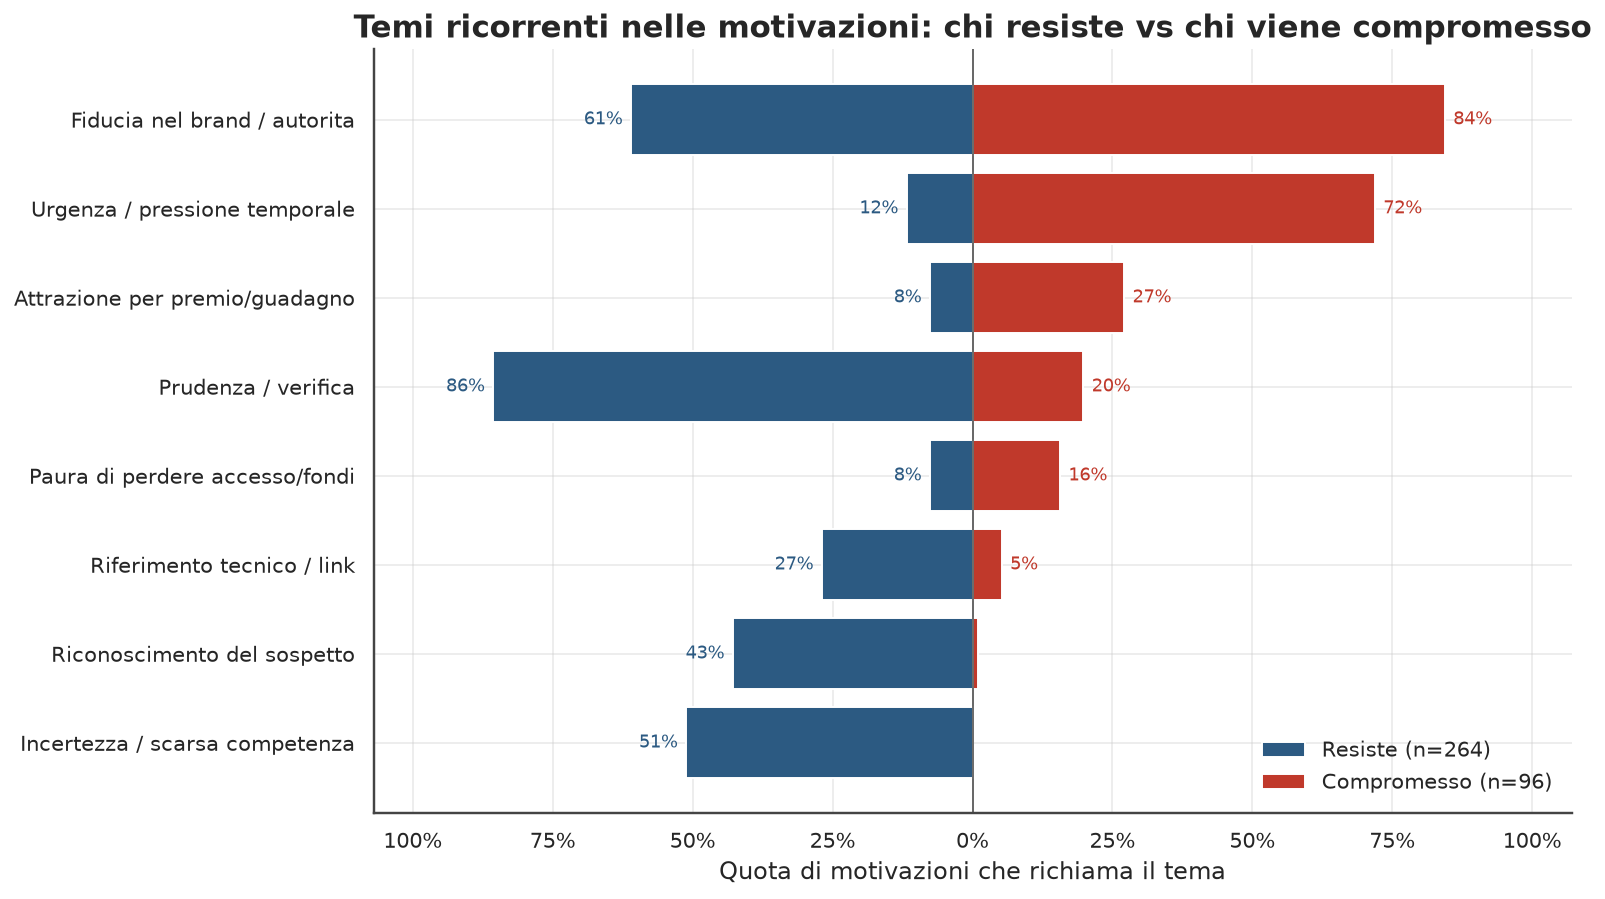

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 13.</b> Frequenza con cui ciascun tema compare nelle motivazioni, confrontando gli agenti compromessi (a destra) e quelli che resistono verificando o segnalando (a sinistra).</div>

In [51]:
import re, unicodedata

def _norm(t):
    t = str(t).lower()
    return unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode()

# Definizione dei temi tramite pattern lessicali (leve del social engineering)
TEMI = {
    "Urgenza / pressione temporale": r"urgen|press|fretta|subito|tempo|scad|veloc",
    "Fiducia nel brand / autorita": r"fiducia|brand|ufficial|affidabil|credo|credibil",
    "Prudenza / verifica": r"verific|control|font|canale|second|prima di",
    "Riconoscimento del sospetto": r"sospett|truffa|phishing|strano|falso|non mi fido|dubbi|insolito|inganno",
    "Paura di perdere accesso/fondi": r"paura|paur|perder|rischio|bloccat|access|fondi",
    "Attrazione per premio/guadagno": r"premio|bonus|guadagn|vincit|airdrop|offert|ricompens|gratis",
    "Riferimento tecnico / link": r"link|sito|\bapp\b|wallet|seed|credenzial|install|remoto",
    "Incertezza / scarsa competenza": r"non so|non ho idea|non capisc|non esperto|incert|non sono sicuro",
}

mot = valide["motivation"].fillna("").map(_norm)
cade = valide["compromised"].astype(bool)
resiste = (valide["verified"].astype(bool) | valide["reported"].astype(bool))
n_cade, n_res = int(cade.sum()), int(resiste.sum())

righe = []
for tema, pat in TEMI.items():
    hit = mot.str.contains(pat, regex=True)
    righe.append([tema,
                  (hit & cade).sum() / max(n_cade, 1),
                  (hit & resiste).sum() / max(n_res, 1)])
temi_df = pd.DataFrame(righe, columns=["tema", "p_cade", "p_resiste"])
temi_df = temi_df.sort_values("p_cade", ascending=True)

fig, ax = plt.subplots(figsize=(11.5, 6.6))
y = np.arange(len(temi_df))
ax.barh(y, -temi_df["p_resiste"], color=NEUTRAL, edgecolor="white", label=f"Resiste (n={n_res})")
ax.barh(y, temi_df["p_cade"], color=ACCENT, edgecolor="white", label=f"Compromesso (n={n_cade})")
for yi, (pc, pr) in enumerate(zip(temi_df["p_cade"], temi_df["p_resiste"])):
    if pc > 0.02:
        ax.text(pc + 0.015, yi, f"{pc:.0%}", va="center", ha="left", fontsize=9.5, color=ACCENT)
    if pr > 0.02:
        ax.text(-pr - 0.015, yi, f"{pr:.0%}", va="center", ha="right", fontsize=9.5, color=NEUTRAL)
ax.set_yticks(y); ax.set_yticklabels(temi_df["tema"])
ax.axvline(0, color="#444", lw=0.8)
lim = max(temi_df["p_cade"].max(), temi_df["p_resiste"].max()) * 1.25
ax.set_xlim(-lim, lim)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{abs(v):.0%}"))
ax.set_xlabel("Quota di motivazioni che richiama il tema")
ax.set_title("Temi ricorrenti nelle motivazioni: chi resiste vs chi viene compromesso")
ax.legend(loc="lower right", frameon=False)
chiudi_figura(fig, "13_motivazioni_temi",
              "Frequenza con cui ciascun tema compare nelle motivazioni, confrontando gli agenti "
              "compromessi (a destra) e quelli che resistono verificando o segnalando (a sinistra).")


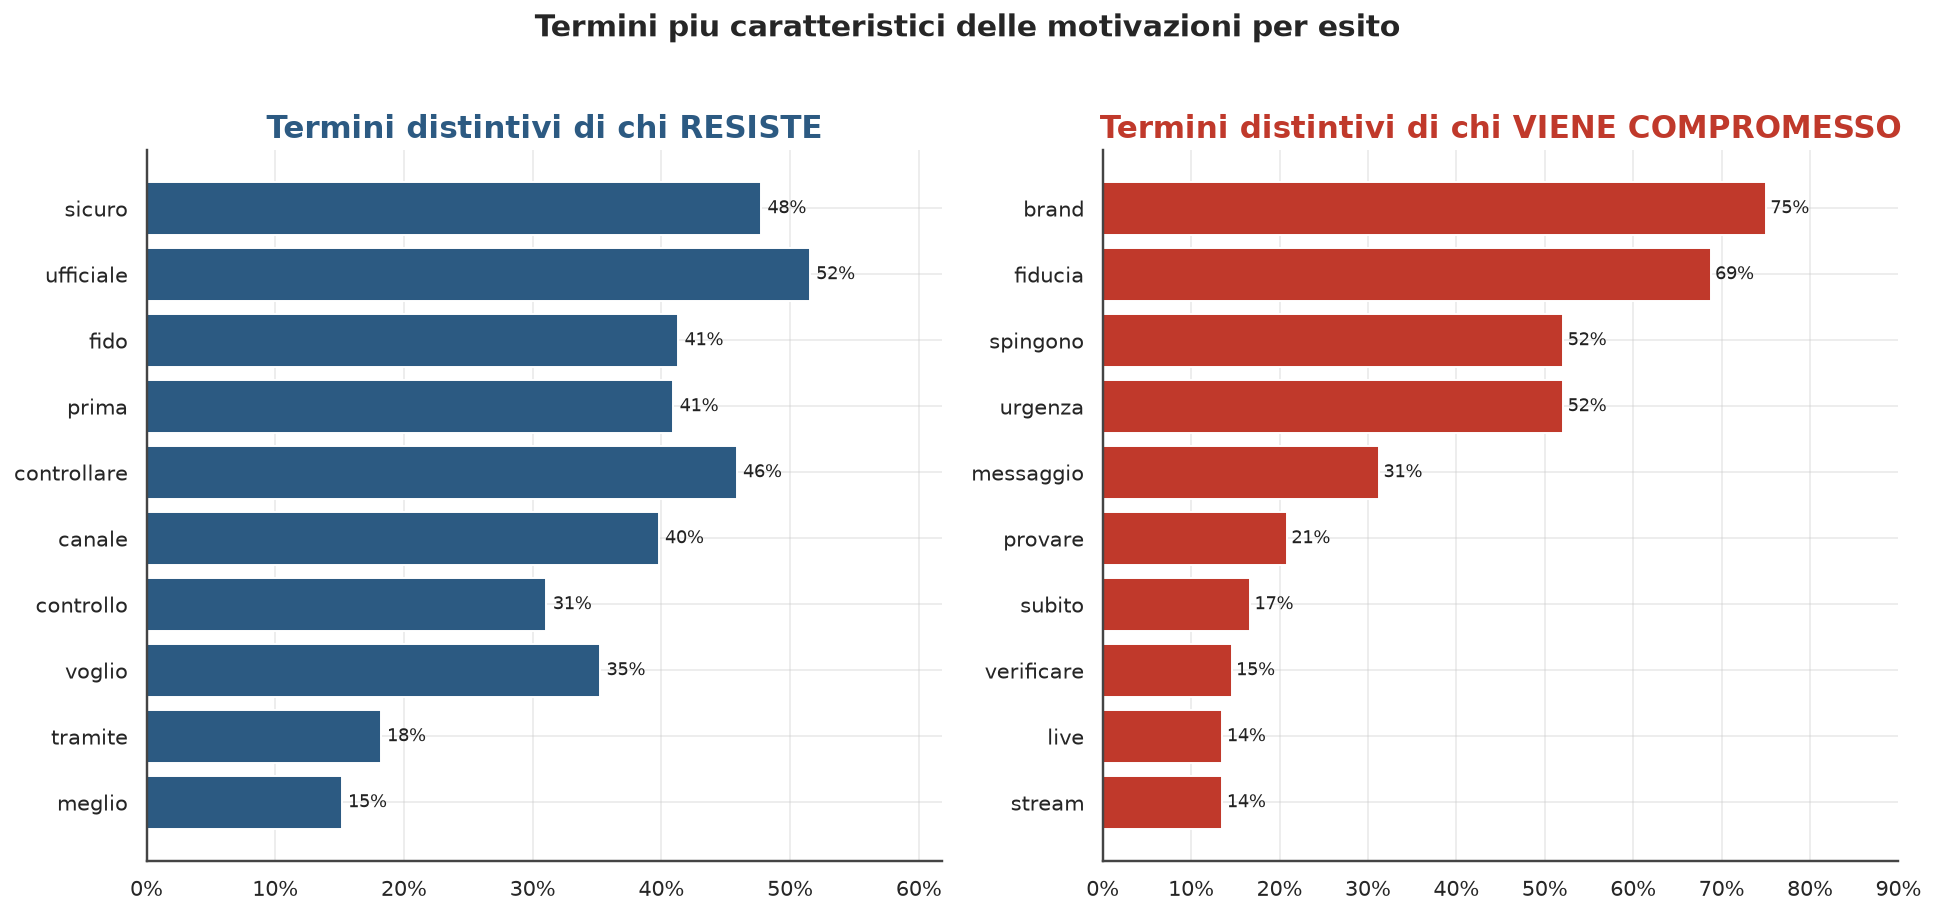

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 14.</b> Termini con la maggiore differenza di frequenza tra i due gruppi: a sinistra quelli tipici di chi resiste, a destra quelli tipici di chi viene compromesso (quota di motivazioni del gruppo che contiene il termine).</div>

In [52]:
from collections import Counter

STOP = set("""il lo la i gli le un uno una di a da in con su per tra fra e o ma se che non ho ha
hai mi ti si ci vi ne del dello della dei degli delle al allo alla ai agli alle dal dalla nel
nella sul sulla come piu meno molto poco ma anche solo perche io tu lui lei noi voi loro questo
questa quello quella sono sia essere fa fare ed cui suo sua mio mia me lo la ce li""".split())

def _tok(s):
    return [w for w in re.findall(r"[a-z]{4,}", _norm(s)) if w not in STOP]

c_cade, c_res = Counter(), Counter()
for s in valide.loc[cade, "motivation"].fillna(""):
    c_cade.update(set(_tok(s)))
for s in valide.loc[resiste, "motivation"].fillna(""):
    c_res.update(set(_tok(s)))

vocab = set(c_cade) | set(c_res)
punteggi = [(w, c_cade[w] / max(n_cade, 1), c_res[w] / max(n_res, 1)) for w in vocab]
top_cade = sorted(punteggi, key=lambda t: t[1] - t[2], reverse=True)[:10][::-1]
top_res = sorted(punteggi, key=lambda t: t[2] - t[1], reverse=True)[:10][::-1]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6.4), sharex=False)
axL.barh([t[0] for t in top_res], [t[2] for t in top_res], color=NEUTRAL, edgecolor="white")
for i, t in enumerate(top_res):
    axL.text(t[2] + 0.005, i, f"{t[2]:.0%}", va="center", fontsize=9.5, color="#222")
axL.set_title("Termini distintivi di chi RESISTE", color=NEUTRAL)
axL.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axL.set_xlim(0, max(t[2] for t in top_res) * 1.2)

axR.barh([t[0] for t in top_cade], [t[1] for t in top_cade], color=ACCENT, edgecolor="white")
for i, t in enumerate(top_cade):
    axR.text(t[1] + 0.005, i, f"{t[1]:.0%}", va="center", fontsize=9.5, color="#222")
axR.set_title("Termini distintivi di chi VIENE COMPROMESSO", color=ACCENT)
axR.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axR.set_xlim(0, max(t[1] for t in top_cade) * 1.2)

fig.suptitle("Termini piu caratteristici delle motivazioni per esito",
             fontsize=15.5, fontweight="bold", y=1.02)
chiudi_figura(fig, "14_motivazioni_termini",
              "Termini con la maggiore differenza di frequenza tra i due gruppi: a sinistra quelli tipici "
              "di chi resiste, a destra quelli tipici di chi viene compromesso (quota di motivazioni del "
              "gruppo che contiene il termine).")


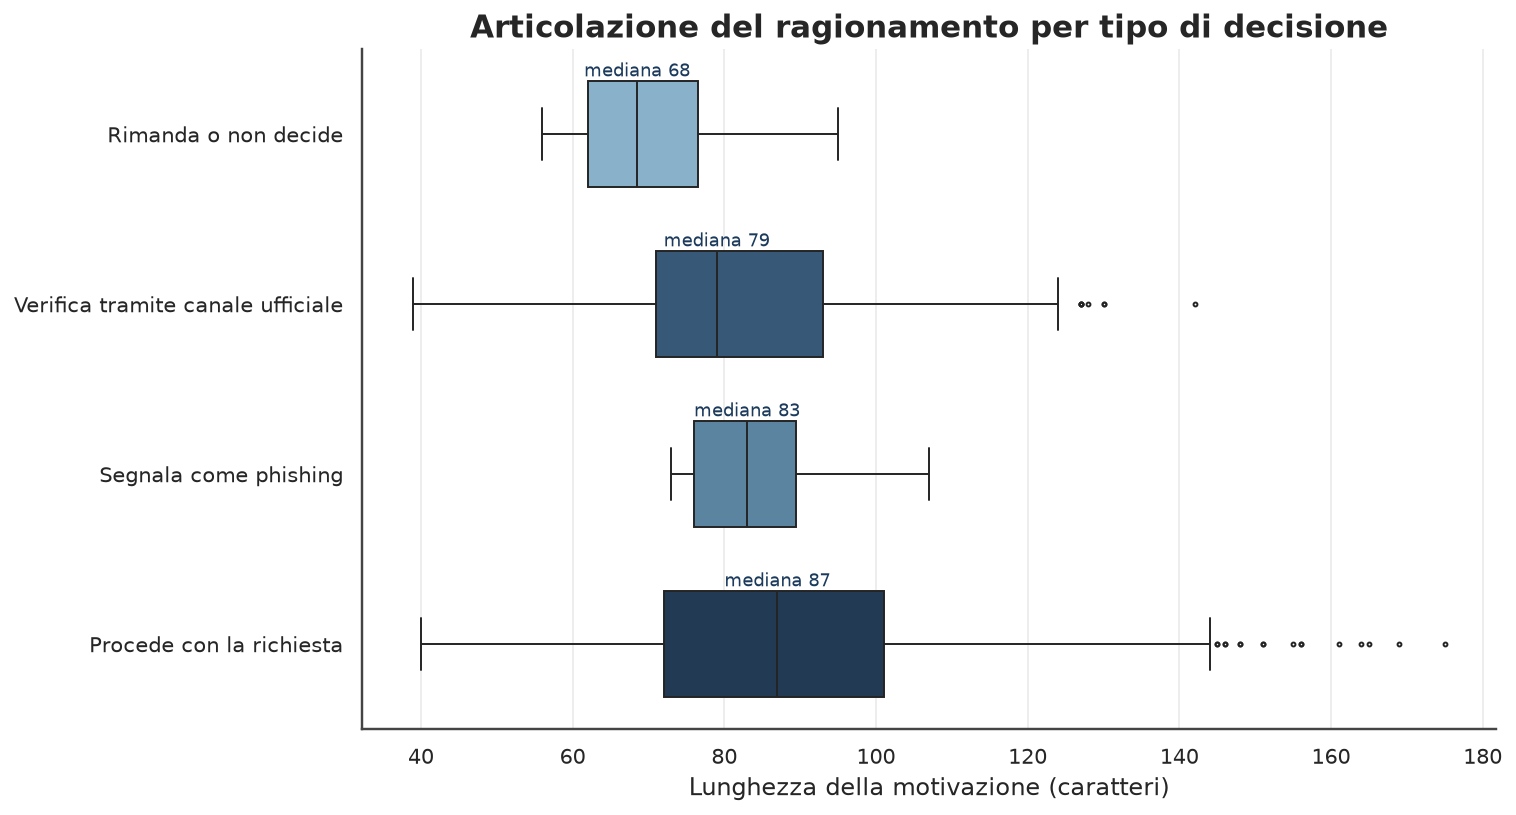

<div style='text-align:center; font-size:12.5px; color:#555555; margin-top:-6px;'><b>Figura 15.</b> Distribuzione della lunghezza delle motivazioni per tipo di decisione iniziale: le scelte prudenti (verifica, segnalazione) tendono a un ragionamento piu articolato rispetto a chi procede.</div>

Esito,Motivazione rappresentativa (piu frequente)
Compromesso,L'idea di guadagnare tanto mi ha fatto agire senza pensare troppo
Verifica tramite canale ufficiale,"Non mi fido di messaggi sospetti, controllo prima con il canale ufficiale."
Segnala come phishing,"Sospetto per l'urgenza e la promessa di raddoppio, non mi fido di brand sconosciuti"


In [53]:
# Articolazione del ragionamento: lunghezza della motivazione per tipo di decisione
tmp = valide.copy()
tmp["dec"] = tmp["decision"].map(etichetta)
tmp["lung"] = tmp["motivation"].fillna("").astype(str).str.len()
ordine_box = (tmp.groupby("dec")["lung"].median().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=tmp, x="lung", y="dec", order=ordine_box, hue="dec",
            palette=PALETTE, legend=False, fliersize=2, width=0.62, ax=ax)
mediane = tmp.groupby("dec")["lung"].median().reindex(ordine_box)
for i, m in enumerate(mediane.values):
    ax.text(m, i - 0.34, f"mediana {int(m)}", ha="center", fontsize=9, color="#1b3a5c")
ax.set_xlabel("Lunghezza della motivazione (caratteri)")
ax.set_ylabel("")
ax.set_title("Articolazione del ragionamento per tipo di decisione")
chiudi_figura(fig, "15_motivazioni_lunghezza",
              "Distribuzione della lunghezza delle motivazioni per tipo di decisione iniziale: le scelte "
              "prudenti (verifica, segnalazione) tendono a un ragionamento piu articolato rispetto a chi "
              "procede.")

# Motivazione piu rappresentativa (moda) per alcuni esiti chiave
def motiv_rappresentativa(mask):
    vc = valide.loc[mask, "motivation"].dropna().astype(str).str.strip()
    vc = vc[vc.str.len() > 0].value_counts()
    return vc.index[0] if len(vc) else "-"

esempi = pd.DataFrame([
    ["Compromesso", motiv_rappresentativa(cade)],
    ["Verifica tramite canale ufficiale", motiv_rappresentativa(valide["verified"].astype(bool))],
    ["Segnala come phishing", motiv_rappresentativa(valide["reported"].astype(bool))],
], columns=["Esito", "Motivazione rappresentativa (piu frequente)"])
display(tabella(esempi, "Motivazione tipo per i principali esiti comportamentali."))
salva_tabella_latex(esempi, "tab08_motivazioni_rappresentative",
                    "Motivazione tipo per i principali esiti comportamentali.")


## 12. Sintesi dei risultati

La sintesi seguente è generata automaticamente a partire dagli indicatori calcolati nelle
sezioni precedenti, in modo da restare sempre coerente con il dataset effettivamente
analizzato; può essere ripresa e ampliata nel capitolo di discussione della tesi.

In [54]:

fascia_top = eta.iloc[0]
scenario_top = scenario.iloc[0]
tasso_compr_phishing = confronto.loc[confronto["message_type"].str.lower().eq(PHISHING_TYPE), "compromesso"].iloc[0]
tasso_compr_legittimo = confronto.loc[confronto["message_type"].str.lower().eq(LEGITIMATE_TYPE), "compromesso"].iloc[0]

osservazioni = [
    f"Il dataset comprende {totale:,} interazioni simulate, di cui il {phishing/totale:.1%} "
    f"riguarda messaggi di phishing e il {legittimo/totale:.1%} messaggi legittimi.",

    f"Il tasso di compromissione osservato sui messaggi di phishing ({tasso_compr_phishing:.1%}) è "
    + ("nettamente superiore" if tasso_compr_phishing > tasso_compr_legittimo * 1.5 else "superiore")
    + f" rispetto a quello sui messaggi legittimi ({tasso_compr_legittimo:.1%}), "
    "a conferma della capacità del framework di discriminare tra le due categorie.",

    f"La fascia d'età con il tasso di compromissione più elevato è **{fascia_top['age_group']}** "
    f"({fascia_top['tasso_compromesso']:.1%} su {int(fascia_top['totale']):,} interazioni), "
    "un dato da approfondire nel capitolo dedicato al profilo di rischio per fascia anagrafica.",

    f"Lo scenario di phishing più efficace è **{etichetta(scenario_top['message_id'])}**, con un tasso di "
    f"compromissione del {scenario_top['tasso_compromesso']:.1%}: la descrizione dello scenario "
    "suggerisce che urgenza e personalizzazione del messaggio incidono significativamente sull'esito.",

    "Gli archetipi con il maggior numero di compromissioni meritano un approfondimento qualitativo "
    "nel capitolo di discussione, incrociando i tratti comportamentali (impulsività, fiducia nei "
    "brand, livello di attenzione) con gli esiti osservati.",
]

from IPython.display import display, Markdown
display(Markdown("\n".join(f"- {o}" for o in osservazioni)))


- Il dataset comprende 960 interazioni simulate, di cui il 80.0% riguarda messaggi di phishing e il 20.0% messaggi legittimi.
- Il tasso di compromissione osservato sui messaggi di phishing (12.5%) è nettamente superiore rispetto a quello sui messaggi legittimi (0.0%), a conferma della capacità del framework di discriminare tra le due categorie.
- La fascia d'età con il tasso di compromissione più elevato è **15-20** (31.7% su 60 interazioni), un dato da approfondire nel capitolo dedicato al profilo di rischio per fascia anagrafica.
- Lo scenario di phishing più efficace è **Twitter: giveaway/match**, con un tasso di compromissione del 24.0%: la descrizione dello scenario suggerisce che urgenza e personalizzazione del messaggio incidono significativamente sull'esito.
- Gli archetipi con il maggior numero di compromissioni meritano un approfondimento qualitativo nel capitolo di discussione, incrociando i tratti comportamentali (impulsività, fiducia nei brand, livello di attenzione) con gli esiti osservati.

## 13. Limiti metodologici

- I risultati derivano da una simulazione basata su agenti LLM e non da un esperimento condotto
  su utenti reali: i tassi riportati sono indicatori relativi interni al disegno sperimentale,
  non stime di prevalenza nel mondo reale.
- Gli archetipi comportamentali sono costrutti sintetici, definiti a priori, e possono non
  rappresentare pienamente la variabilità di un campione di popolazione reale.
- Le percentuali osservate dipendono dal modello linguistico utilizzato (`qwen3:8b`), dalla
  formulazione dei prompt, dalla temperatura di campionamento e dallo schema di validazione
  delle risposte JSON adottato dalla pipeline di simulazione.
- Il numero di archetipi e di scenari, per quanto ampio, resta finito: i risultati non vanno
  estrapolati a scenari di phishing non rappresentati nel dataset.
- Un'eventuale variazione del modello, della temperatura o del seed di generazione può produrre
  distribuzioni di decisione diverse; per la riproducibilità si rimanda ai parametri riportati
  nella Sezione 1.


## 14. Asset pronti per l'inclusione in LaTeX

Ogni volta che questo notebook viene eseguito, oltre a mostrare grafici e tabelle a schermo,
salva automaticamente su disco gli **asset nativi** da includere nella tesi:

- le figure, in formato **PDF vettoriale** (qualità di stampa, ridimensionabile senza perdita)
  e PNG, in `results/plots/thesis/`;
- le tabelle, come frammenti **`.tex` con `booktabs`**, già numerate e con didascalia, in
  `results/plots/thesis/tables/`.

Questo evita di dover esportare l'intero notebook in PDF (HTML/CSS e le tabelle pandas non hanno
una traduzione diretta in LaTeX): ogni figura e ogni tabella vengono incluse singolarmente, con
lo stesso font e la stessa numerazione del resto della tesi.

**Nel preambolo della tesi**, assicurarsi che siano caricati i pacchetti:

```latex
\usepackage{graphicx}
\usepackage{booktabs}
```

**Per includere una figura** (es. Figura 4, tasso di compromissione per fascia d'età):

```latex
\begin{figure}[htbp]
  \centering
  \includegraphics[width=0.85\textwidth]{figure/04_compromissione_per_eta.pdf}
  \caption{Tasso di compromissione per fascia d'età.}
  \label{fig:compromissione-per-eta}
\end{figure}
```

**Per includere una tabella** (es. Tabella 4, stessa figura): il file `.tex` contiene già
l'intero ambiente `table` con didascalia e label, quindi basta un `\input`:

```latex
\input{tabelle/tab04_compromissione_per_eta.tex}
```

Copiare il contenuto di `results/plots/thesis/` (PDF/PNG) e `results/plots/thesis/tables/`
(`.tex`) nelle rispettive cartelle del progetto LaTeX (es. `figure/` e `tabelle/`), oppure
puntare `\graphicspath{}` direttamente a `results/plots/thesis/`.

In [55]:

print("Figure esportate (PDF + PNG) in results/plots/thesis/:")
for p in sorted(FIG_DIR.glob("*.pdf")):
    print(" -", p.name)

print()
print("Tabelle esportate (.tex, pronte per \\input) in results/plots/thesis/tables/:")
for p in sorted(TABLE_DIR.glob("*.tex")):
    print(" -", p.name)


Figure esportate (PDF + PNG) in results/plots/thesis/:
 - 01_composizione_dataset.pdf
 - 02_distribuzione_decisioni.pdf
 - 03_esiti_flusso.pdf
 - 04_compromissione_per_eta.pdf
 - 05_top10_scenari_phishing.pdf
 - 06_confronto_indicatori.pdf
 - 07_tratti_dose_risposta.pdf
 - 08_ranking_archetipi.pdf
 - 09_decisioni_per_archetipo.pdf
 - 10_heatmap_archetipo_scenario.pdf
 - 11_funnel_compromissione.pdf
 - 12_fattori_contesto.pdf
 - 13_motivazioni_temi.pdf
 - 14_motivazioni_termini.pdf
 - 15_motivazioni_lunghezza.pdf

Tabelle esportate (.tex, pronte per \input) in results/plots/thesis/tables/:
 - tab01_provenienza_dati.tex
 - tab02_composizione_dataset.tex
 - tab04_compromissione_per_eta.tex
 - tab05_top10_scenari_phishing.tex
 - tab06_confronto_phishing_legittimi.tex
 - tab07_vulnerabilita_archetipi.tex
 - tab08_motivazioni_rappresentative.tex
